### 📘 Pandas 수업 정리 문서 (1~7주차)

---

##### ✅ 1주차: Pandas Series 기초

##### 🔹 Series 생성 및 속성 확인

In [1]:
import pandas as pd
import numpy as np

# 간단한 Series 생성
s = pd.Series([1, 3, 5, np.nan, 6, 8], name='first')

s

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
Name: first, dtype: float64

In [2]:
# 속성 확인
print('name : ', s.name)
print('index : ', s.index)
print('values : ', s.values)
print('shape : ', s.shape)
print('size : ', s.size)

name :  first
index :  RangeIndex(start=0, stop=6, step=1)
values :  [ 1.  3.  5. nan  6.  8.]
shape :  (6,)
size :  6


In [3]:
s.index = np.arange(1, 7)

s.index

Index([1, 2, 3, 4, 5, 6], dtype='int64')

##### 🔹 인덱싱 및 슬라이싱

In [4]:
s

1    1.0
2    3.0
3    5.0
4    NaN
5    6.0
6    8.0
Name: first, dtype: float64

In [5]:
# 위치 기반 인덱싱
print('s[1] : ', s[1], '\n')
print(s[1:5])

# 값 수정
s[2] = 50
s

s[1] :  1.0 

2    3.0
3    5.0
4    NaN
5    6.0
Name: first, dtype: float64


1     1.0
2    50.0
3     5.0
4     NaN
5     6.0
6     8.0
Name: first, dtype: float64

##### 🔹 라벨 기반 인덱싱 및 인덱스 변경

In [6]:
# 인덱스 라벨 변경
s.index = list('abcdef')
print(s, '\n')

# 라벨 기반 접근
print("s['a'] : ", s['a'])

s['a':'d']

a     1.0
b    50.0
c     5.0
d     NaN
e     6.0
f     8.0
Name: first, dtype: float64 

s['a'] :  1.0


a     1.0
b    50.0
c     5.0
d     NaN
Name: first, dtype: float64

##### 🔹 고급 인덱싱 (리스트 사용)

In [7]:
# 여러 위치 혹은 라벨을 리스트로 지정하여 접근
age = pd.Series([9, 17, 32, 45, 65, 98], index=list('abcdef'), name='age')
print(age, '\n')

print(age['f'], type(age['f']), '\n')

print(age[[1, 3, 5]], '\n')
print(age[['a', 'c']], '\n')
print(age[['f']])

a     9
b    17
c    32
d    45
e    65
f    98
Name: age, dtype: int64 

98 <class 'numpy.int64'> 

b    17
d    45
f    98
Name: age, dtype: int64 

a     9
c    32
Name: age, dtype: int64 

f    98
Name: age, dtype: int64


C:\Users\asus\AppData\Local\Temp\ipykernel_16208\2032397699.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(age[[1, 3, 5]], '\n')


##### 🔹 불리언 인덱싱

In [8]:
# 조건에 따라 필터링
s = pd.Series([3, 6, -3, 0, -4, 8, -7])
print(s, '\n')

print(s[s > 0], '\n')
print(s[s % 2 == 0], '\n')

0    3
1    6
2   -3
3    0
4   -4
5    8
6   -7
dtype: int64 

0    3
1    6
5    8
dtype: int64 

1    6
3    0
4   -4
5    8
dtype: int64 



##### 🔹 기타 환경 설정 및 시각화

In [9]:
import sys

sys.version

'3.12.5 | packaged by conda-forge | (main, Aug  8 2024, 18:24:51) [MSC v.1940 64 bit (AMD64)]'

In [10]:
import site

site.getsitepackages()

['c:\\Users\\asus\\anaconda3\\envs\\dmu',
 'c:\\Users\\asus\\anaconda3\\envs\\dmu\\Lib\\site-packages']

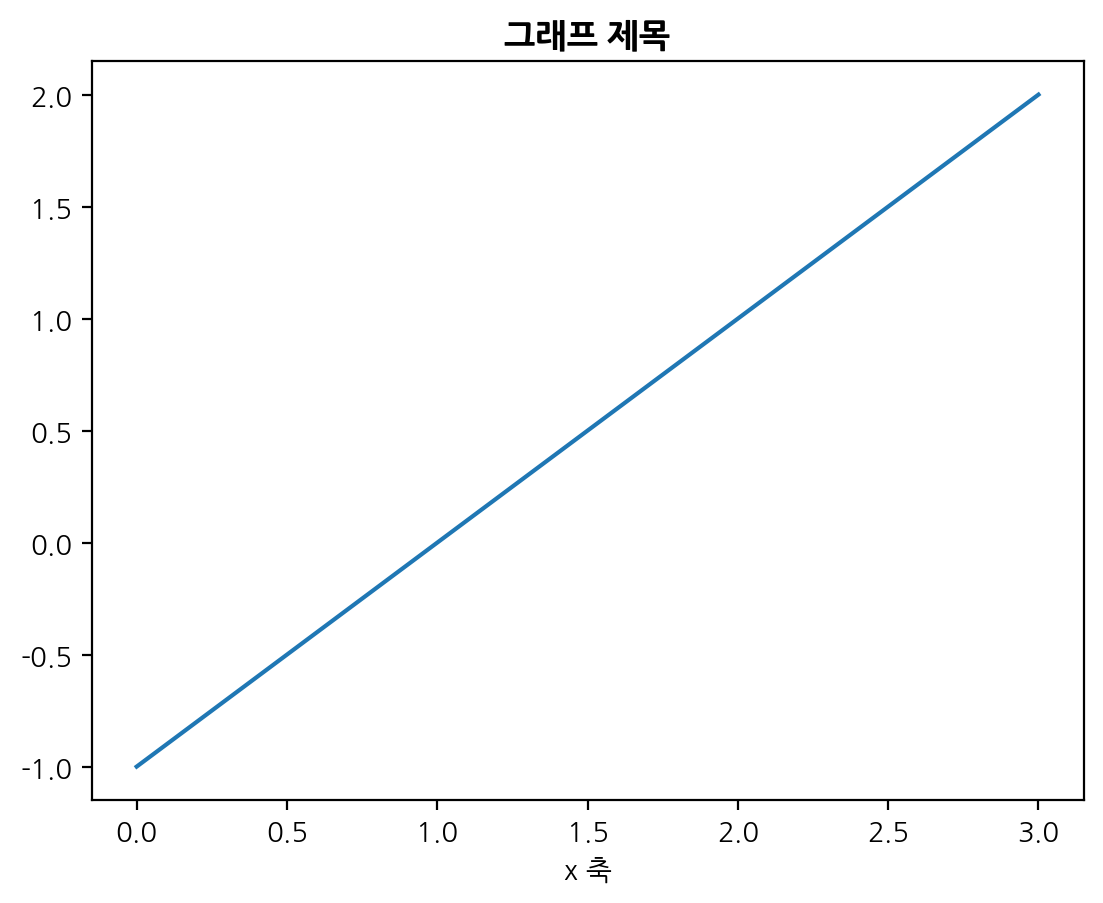

In [11]:
# 한글 폰트 설정 및 간단한 그래프
import matplotlib.pyplot as plt
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

plt.plot([-1, 0, 1, 2])
plt.title('그래프 제목', fontweight = 'bold')
plt.xlabel('x 축')
plt.show()

##### ✅ 2주차: DataFrame 기초 및 참조

##### 🔹 DataFrame 구조 이해 및 생성

In [12]:
# 예제 데이터프레임 생성
pf = pd.DataFrame(data = [[25, 35, 8, 18], 
                          [18, 27, 10, 20], 
                          [17, 17, 10, 19], 
                          [12, 22, 9, 20], 
                          [22, 34, 8, 16]], 
                  index=['윤일형', '강수희', '홍소희', '유한빈', '신수빈'],
                  columns=['중간', '기말', '과제', '출석'])

pf

,중간,기말,과제,출석
윤일형,25,35,8,18
강수희,18,27,10,20
홍소희,17,17,10,19
유한빈,12,22,9,20
신수빈,22,34,8,16


##### 🔹 `.loc[]`, `.iloc[]`, `.at[]`, `.iat[]` 위치/라벨 기반 접근

In [13]:
# 라벨 기반 접근
print(pf.loc['윤일형', '기말'], '\n')
print(pf.loc['윤일형':'유한빈', '기말':'과제'])

35 

     기말  과제
윤일형  35   8
강수희  27  10
홍소희  17  10
유한빈  22   9


In [14]:
# 위치 기반 접근
# iloc : integer location (인덱스 활용)
print(pf.iloc[1], '\n')
print(pf.iloc[[1, 3], :], '\n')
print(pf.iloc[1:3, 1:])

중간    18
기말    27
과제    10
출석    20
Name: 강수희, dtype: int64 

     중간  기말  과제  출석
강수희  18  27  10  20
유한빈  12  22   9  20 

     기말  과제  출석
강수희  27  10  20
홍소희  17  10  19


In [15]:
# 단일값 빠르게 접근
print(pf.at['윤일형', '과제'], '\n')
print(pf.iat[2, 3])

8 

19


##### 🔹 인덱스 및 열 이름 추출

In [16]:
pf.index[0]

'윤일형'

In [17]:
pf.columns[1]

'기말'

In [18]:
print('index : ', pf.index)
print('columns : ', pf.columns)
print(pf.loc[pf.index[0], pf.columns[1]])
print(pf.loc['윤일형', '기말'])

index :  Index(['윤일형', '강수희', '홍소희', '유한빈', '신수빈'], dtype='object')
columns :  Index(['중간', '기말', '과제', '출석'], dtype='object')
35
35


##### 🔹 부분 선택 및 참조

In [19]:
# 다양한 행/열 선택 조합
print(pf.iloc[:, 1:], '\n')
print(pf.iloc[[1, 4, 3], 1:], '\n')
print(pf.iloc[[1, 3, 4], [0, 1]])

     기말  과제  출석
윤일형  35   8  18
강수희  27  10  20
홍소희  17  10  19
유한빈  22   9  20
신수빈  34   8  16 

     기말  과제  출석
강수희  27  10  20
신수빈  34   8  16
유한빈  22   9  20 

     중간  기말
강수희  18  27
유한빈  12  22
신수빈  22  34


##### 🔹 Series 슬라이싱 활용

In [20]:
pf['기말']

윤일형    35
강수희    27
홍소희    17
유한빈    22
신수빈    34
Name: 기말, dtype: int64

In [21]:
print(pf['기말'][1:3], '\n')
print(pf['기말'].iloc[0:2])

강수희    27
홍소희    17
Name: 기말, dtype: int64 

윤일형    35
강수희    27
Name: 기말, dtype: int64


##### ✅ 3주차: 데이터프레임 연산 및 필터링

##### 🔹 데이터 불러오기 및 정보 확인

In [22]:
# CSV 파일 불러오기 및 요약 정보
import pandas as pd
df = pd.read_csv('./data/2016년졸음운전.csv', encoding='euc-kr')

print(df.info(), '\n')

print(df.describe(), '\n')

df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   연월      12 non-null     object
 1   사고(건)   12 non-null     int64 
 2   사망(명)   12 non-null     int64 
 3   부상(명)   12 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 516.0+ bytes
None 

            사고(건)      사망(명)       부상(명)
count   12.000000  12.000000   12.000000
mean   202.750000   8.166667  408.250000
std     23.014324   3.186144   60.051682
min    168.000000   4.000000  328.000000
25%    186.000000   5.750000  363.500000
50%    200.000000   7.000000  402.500000
75%    219.500000  10.500000  441.250000
max    239.000000  13.000000  522.000000 



연월       object
사고(건)     int64
사망(명)     int64
부상(명)     int64
dtype: object

##### 🔹 수치 연산

In [23]:
df

,연월,사고(건),사망(명),부상(명)
0,2016년1월,192,5,387
1,2016년2월,174,6,328
2,2016년3월,217,7,435
3,2016년4월,216,7,419
4,2016년5월,239,13,522
5,2016년6월,200,12,362
6,2016년7월,227,9,460
7,2016년8월,230,7,490
8,2016년9월,187,13,347
9,2016년10월,183,10,367


In [24]:
# 집계 함수 활용
print(df.sum(), '\n')

print(df.mean(numeric_only=True), '\n')

# number, int64
print(df.select_dtypes(include='number').cumsum().head(), '\n')

print(df.max(), '\n')

print(df.shape)

연월       2016년1월2016년2월2016년3월2016년4월2016년5월2016년6월2016...
사고(건)                                                 2433
사망(명)                                                   98
부상(명)                                                 4899
dtype: object 

사고(건)    202.750000
사망(명)      8.166667
부상(명)    408.250000
dtype: float64 

   사고(건)  사망(명)  부상(명)
0    192      5    387
1    366     11    715
2    583     18   1150
3    799     25   1569
4   1038     38   2091 

연월       2016년9월
사고(건)        239
사망(명)         13
부상(명)        522
dtype: object 

(12, 4)


##### 🔹 새로운 열 추가 및 총계 처리

In [25]:
# 열 추가 및 총합 행 생성
df2 = df.copy()

df2['재해자수'] = df[['사망(명)', '부상(명)']].sum(axis=1)

df2.loc['총계'] = df2.sum(numeric_only=True)

df2

df3 = df2.copy()

##### 🔹 조건 필터링

In [26]:
df2

,연월,사고(건),사망(명),부상(명),재해자수
0,2016년1월,192.0,5.0,387.0,392.0
1,2016년2월,174.0,6.0,328.0,334.0
2,2016년3월,217.0,7.0,435.0,442.0
3,2016년4월,216.0,7.0,419.0,426.0
4,2016년5월,239.0,13.0,522.0,535.0
5,2016년6월,200.0,12.0,362.0,374.0
6,2016년7월,227.0,9.0,460.0,469.0
7,2016년8월,230.0,7.0,490.0,497.0
8,2016년9월,187.0,13.0,347.0,360.0
9,2016년10월,183.0,10.0,367.0,377.0


In [27]:
# 특정 조건에 맞는 행 필터링
print(df2[df2['재해자수'] > 400], '\n')
print(df2[df2['사망(명)'] == 7], '\n')
print(df2[df2['사망(명)'].isin([7, 10])], '\n')

# '총계' 항목으로 인해 오류
# df2[df2.index.str.contains('3')]
df2[df2.index.astype(str).str.contains('3')]

          연월   사고(건)  사망(명)   부상(명)    재해자수
2    2016년3월   217.0    7.0   435.0   442.0
3    2016년4월   216.0    7.0   419.0   426.0
4    2016년5월   239.0   13.0   522.0   535.0
6    2016년7월   227.0    9.0   460.0   469.0
7    2016년8월   230.0    7.0   490.0   497.0
10  2016년11월   200.0    5.0   418.0   423.0
총계       NaN  2433.0   98.0  4899.0  4997.0 

        연월  사고(건)  사망(명)  부상(명)   재해자수
2  2016년3월  217.0    7.0  435.0  442.0
3  2016년4월  216.0    7.0  419.0  426.0
7  2016년8월  230.0    7.0  490.0  497.0 

         연월  사고(건)  사망(명)  부상(명)   재해자수
2   2016년3월  217.0    7.0  435.0  442.0
3   2016년4월  216.0    7.0  419.0  426.0
7   2016년8월  230.0    7.0  490.0  497.0
9  2016년10월  183.0   10.0  367.0  377.0 



,연월,사고(건),사망(명),부상(명),재해자수
3,2016년4월,216.0,7.0,419.0,426.0


##### 🔹 `query()` 함수 활용

In [28]:
df_e = pd.DataFrame({'A':range(1, 6), 
                   'B':range(6, -3, -2), 
                   'C':range(10, 5, -1), 
                   'D':range(3, -2, -1), 
                   'E':['python', 'java', 'html', 'css', 'go']})
df_e

,A,B,C,D,E
0,1,6,10,3,python
1,2,4,9,2,java
2,3,2,8,1,html
3,4,0,7,0,css
4,5,-2,6,-1,go


In [29]:
# 문자열 기반 조건 필터링
print(df_e.query('A > B'), '\n')   
print(df_e.query('E == "python"'), '\n')
print(df_e.query('A > 2 & C < 8'), '\n')
print(df_e.query('E in ["python", "go"]'))

   A  B  C  D     E
2  3  2  8  1  html
3  4  0  7  0   css
4  5 -2  6 -1    go 

   A  B   C  D       E
0  1  6  10  3  python 

   A  B  C  D    E
3  4  0  7  0  css
4  5 -2  6 -1   go 

   A  B   C  D       E
0  1  6  10  3  python
4  5 -2   6 -1      go


##### 🔹 문자열 필터링

In [30]:
# 문자열 처리
s = df_e.E
print(s.str.contains('py'), '\n')
print(s.str.startswith('g'), '\n')
print(s.str.endswith('on'))

0     True
1    False
2    False
3    False
4    False
Name: E, dtype: bool 

0    False
1    False
2    False
3    False
4     True
Name: E, dtype: bool 

0     True
1    False
2    False
3    False
4    False
Name: E, dtype: bool


##### 🔹 정렬

In [31]:
# 행/열 기준 정렬
print(df.sort_index(), '\n')

print(df.sort_values(by='사망(명)'), '\n')

          연월  사고(건)  사망(명)  부상(명)
0    2016년1월    192      5    387
1    2016년2월    174      6    328
2    2016년3월    217      7    435
3    2016년4월    216      7    419
4    2016년5월    239     13    522
5    2016년6월    200     12    362
6    2016년7월    227      9    460
7    2016년8월    230      7    490
8    2016년9월    187     13    347
9   2016년10월    183     10    367
10  2016년11월    200      5    418
11  2016년12월    168      4    364 

          연월  사고(건)  사망(명)  부상(명)
11  2016년12월    168      4    364
0    2016년1월    192      5    387
10  2016년11월    200      5    418
1    2016년2월    174      6    328
7    2016년8월    230      7    490
3    2016년4월    216      7    419
2    2016년3월    217      7    435
6    2016년7월    227      9    460
9   2016년10월    183     10    367
5    2016년6월    200     12    362
4    2016년5월    239     13    522
8    2016년9월    187     13    347 



In [32]:
print(df.sort_index(), '\n')

          연월  사고(건)  사망(명)  부상(명)
0    2016년1월    192      5    387
1    2016년2월    174      6    328
2    2016년3월    217      7    435
3    2016년4월    216      7    419
4    2016년5월    239     13    522
5    2016년6월    200     12    362
6    2016년7월    227      9    460
7    2016년8월    230      7    490
8    2016년9월    187     13    347
9   2016년10월    183     10    367
10  2016년11월    200      5    418
11  2016년12월    168      4    364 



In [33]:
# 열 기준 정렬도 가능 (axis=1)
print(df.sort_index(axis=1), '\n')

df2 = df.set_index('연월')
# 열 정렬 기준을 2016년12월 값의 크기로 정렬
print(df2.sort_values(by='2016년12월', axis=1))

    부상(명)  사고(건)  사망(명)        연월
0     387    192      5   2016년1월
1     328    174      6   2016년2월
2     435    217      7   2016년3월
3     419    216      7   2016년4월
4     522    239     13   2016년5월
5     362    200     12   2016년6월
6     460    227      9   2016년7월
7     490    230      7   2016년8월
8     347    187     13   2016년9월
9     367    183     10  2016년10월
10    418    200      5  2016년11월
11    364    168      4  2016년12월 

          사망(명)  사고(건)  부상(명)
연월                           
2016년1월       5    192    387
2016년2월       6    174    328
2016년3월       7    217    435
2016년4월       7    216    419
2016년5월      13    239    522
2016년6월      12    200    362
2016년7월       9    227    460
2016년8월       7    230    490
2016년9월      13    187    347
2016년10월     10    183    367
2016년11월      5    200    418
2016년12월      4    168    364


##### 🔹 값 수정

In [34]:
# 특정 위치의 값 변경
df_e.at[df_e.index[-1], df_e.columns[-1]] = 230
print(df_e, '\n')

df_e.iat[3, 3] = 150
print(df_e, '\n')

df_e.iloc[:, 4] = [500] * len(df_e)
print(df_e)

   A  B   C  D       E
0  1  6  10  3  python
1  2  4   9  2    java
2  3  2   8  1    html
3  4  0   7  0     css
4  5 -2   6 -1     230 

   A  B   C    D       E
0  1  6  10    3  python
1  2  4   9    2    java
2  3  2   8    1    html
3  4  0   7  150     css
4  5 -2   6   -1     230 

   A  B   C    D    E
0  1  6  10    3  500
1  2  4   9    2  500
2  3  2   8    1  500
3  4  0   7  150  500
4  5 -2   6   -1  500


##### 🔹 결측값 처리

In [35]:
# 결측치 확인 및 채우기
df2.isna()
df2.dropna()
df2.fillna(500)

,사고(건),사망(명),부상(명)
연월,,,
2016년1월,192,5,387
2016년2월,174,6,328
2016년3월,217,7,435
2016년4월,216,7,419
2016년5월,239,13,522
2016년6월,200,12,362
2016년7월,227,9,460
2016년8월,230,7,490
2016년9월,187,13,347


##### ✅ 4주차: 결측값 처리, 시각화, 그룹 분석

##### 🔹 결측값 처리 방법

In [36]:
df_nan = pd.DataFrame([[np.nan, 2, np.nan, 0],
                   [3, 4, np.nan, 1],
                   [np.nan, np.nan, np.nan, np.nan],
                   [np.nan, 3, np.nan, 4]],
                  columns=list("ABCD"))
df_nan

,A,B,C,D
0,NaN,2.0,NaN,0.0
1,3.0,4.0,NaN,1.0
2,NaN,NaN,NaN,NaN
3,NaN,3.0,NaN,4.0


In [37]:
# 다양한 결측값 채우기 방법
print(df_nan.fillna(10), '\n')

print(df_nan.fillna('missing'), '\n')

print(df_nan.fillna({'A': 100, 'B': 200}), '\n')

print(df_nan.fillna(method='ffill', limit=1), '\n')

      A     B     C     D
0  10.0   2.0  10.0   0.0
1   3.0   4.0  10.0   1.0
2  10.0  10.0  10.0  10.0
3  10.0   3.0  10.0   4.0 

         A        B        C        D
0  missing      2.0  missing      0.0
1      3.0      4.0  missing      1.0
2  missing  missing  missing  missing
3  missing      3.0  missing      4.0 

       A      B   C    D
0  100.0    2.0 NaN  0.0
1    3.0    4.0 NaN  1.0
2  100.0  200.0 NaN  NaN
3  100.0    3.0 NaN  4.0 

     A    B   C    D
0  NaN  2.0 NaN  0.0
1  3.0  4.0 NaN  1.0
2  3.0  4.0 NaN  1.0
3  NaN  3.0 NaN  4.0 



C:\Users\asus\AppData\Local\Temp\ipykernel_16208\1101230936.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  print(df_nan.fillna(method='ffill', limit=1), '\n')


In [38]:
# bfill : backward fill
print(df_nan.bfill(limit=1, axis=1), '\n')

print(df_nan.fillna(df_nan.mean()))

     A    B    C    D
0  2.0  2.0  0.0  0.0
1  3.0  4.0  1.0  1.0
2  NaN  NaN  NaN  NaN
3  3.0  3.0  4.0  4.0 

     A    B   C         D
0  3.0  2.0 NaN  0.000000
1  3.0  4.0 NaN  1.000000
2  3.0  3.0 NaN  1.666667
3  3.0  3.0 NaN  4.000000


##### 🔹 외부 데이터셋 사용 (타이타닉)

In [39]:
# 타이타닉 데이터셋 불러오기 및 확인
import seaborn as sns

ttn = sns.load_dataset("titanic")

ttn.info()
ttn.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [40]:
ttn[['pclass', 'sex', 'alive']].value_counts().sort_index()

pclass  sex     alive
1       female  no         3
                yes       91
        male    no        77
                yes       45
2       female  no         6
                yes       70
        male    no        91
                yes       17
3       female  no        72
                yes       72
        male    no       300
                yes       47
Name: count, dtype: int64

##### 🔹 그룹화 및 통계

In [41]:
# groupby를 이용한 집계
print(ttn.groupby('sex').count(), '\n')

# fare : 요금
print(ttn.groupby('alive')['fare'].mean(), '\n')

print(ttn.groupby('pclass')['fare'].mean())

        survived  pclass  age  sibsp  parch  fare  embarked  class  who  \
sex                                                                       
female       314     314  261    314    314   314       312    314  314   
male         577     577  453    577    577   577       577    577  577   

        adult_male  deck  embark_town  alive  alone  
sex                                                  
female         314    97          312    314    314  
male           577   106          577    577    577   

alive
no     22.117887
yes    48.395408
Name: fare, dtype: float64 

pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64


##### 🔹 시각화 (Seaborn)

<Axes: xlabel='sex', ylabel='count'>

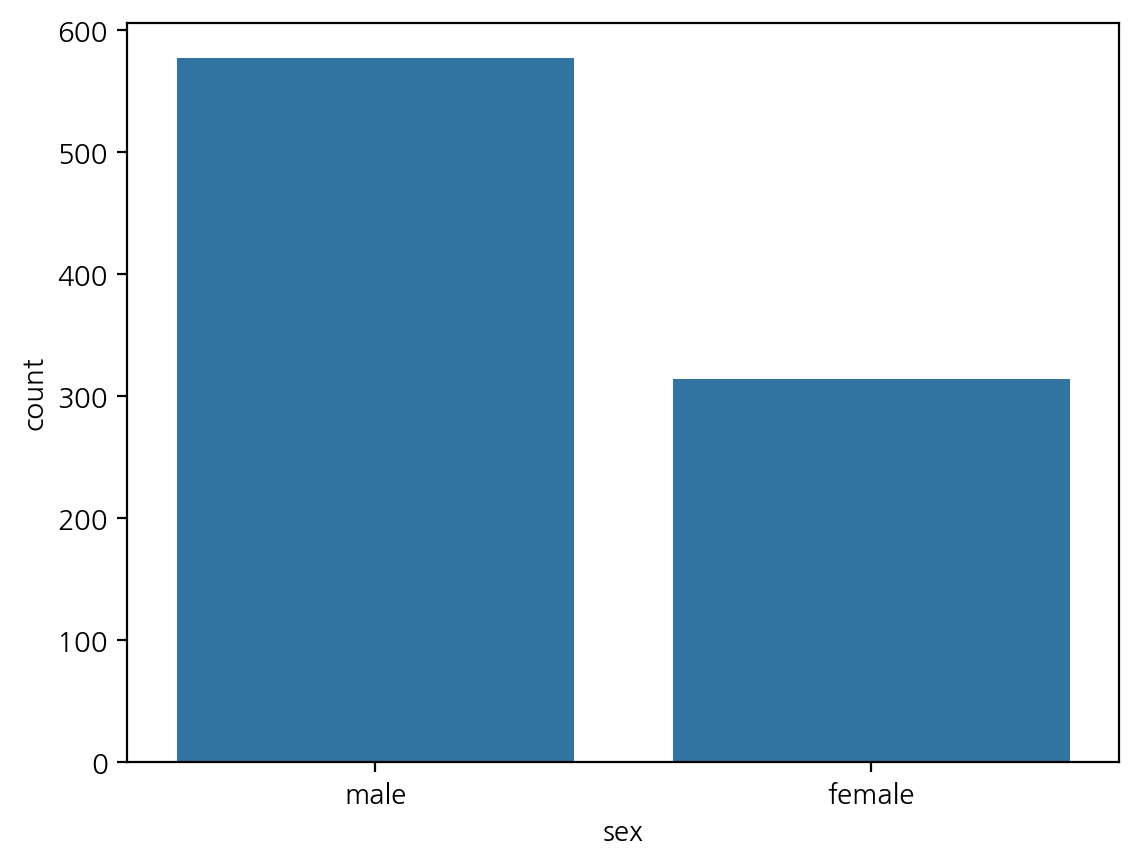

In [42]:
# 범주형 변수 시각화
sns.countplot(ttn, x='sex')

<Axes: xlabel='class', ylabel='count'>

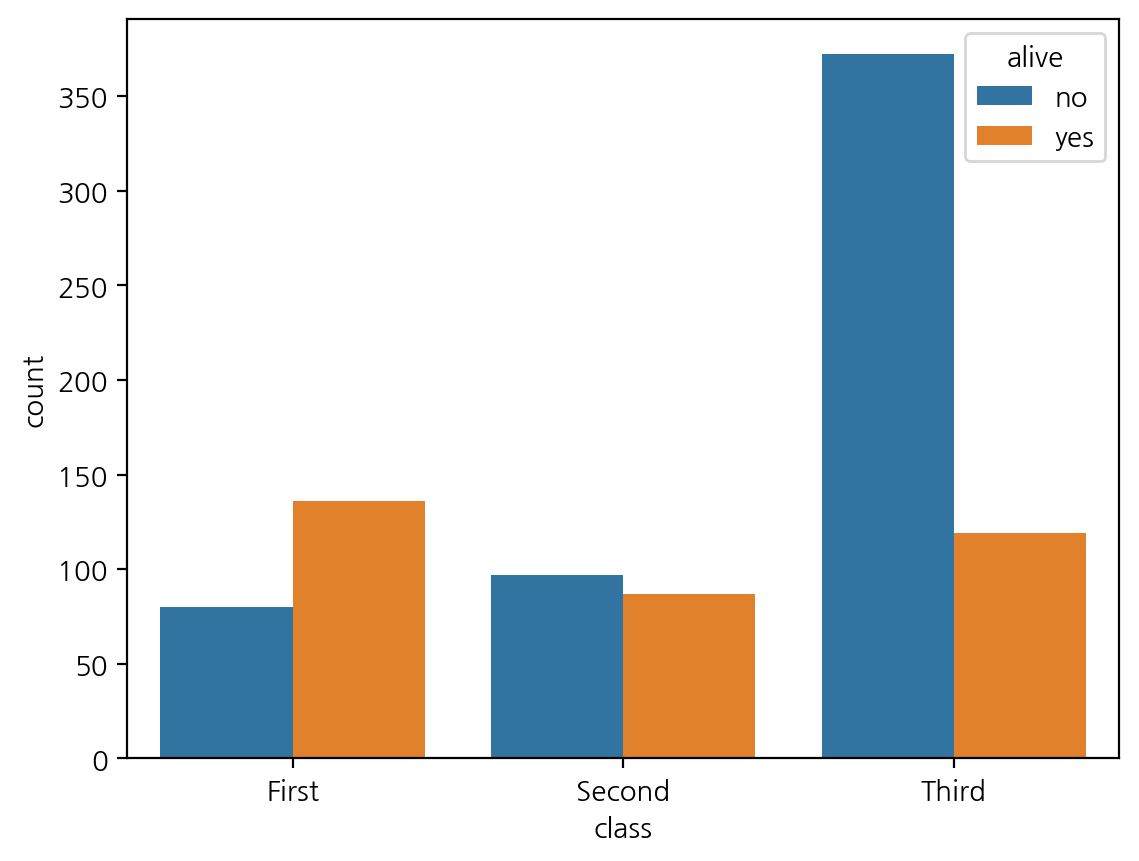

In [43]:
sns.countplot(ttn, x='class', hue='alive')

<Axes: xlabel='pclass', ylabel='survived'>

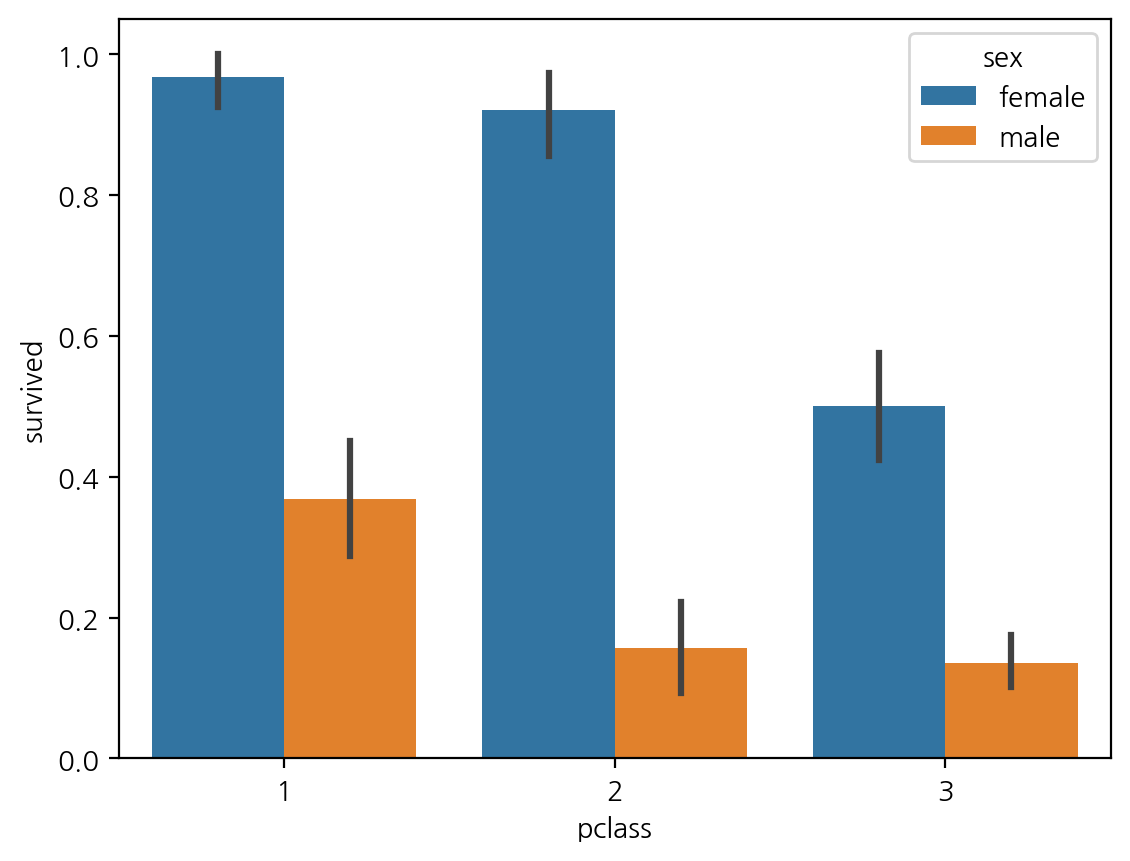

In [44]:
sns.barplot(ttn, x='pclass', y='survived', hue='sex')

<Axes: xlabel='deck', ylabel='fare'>

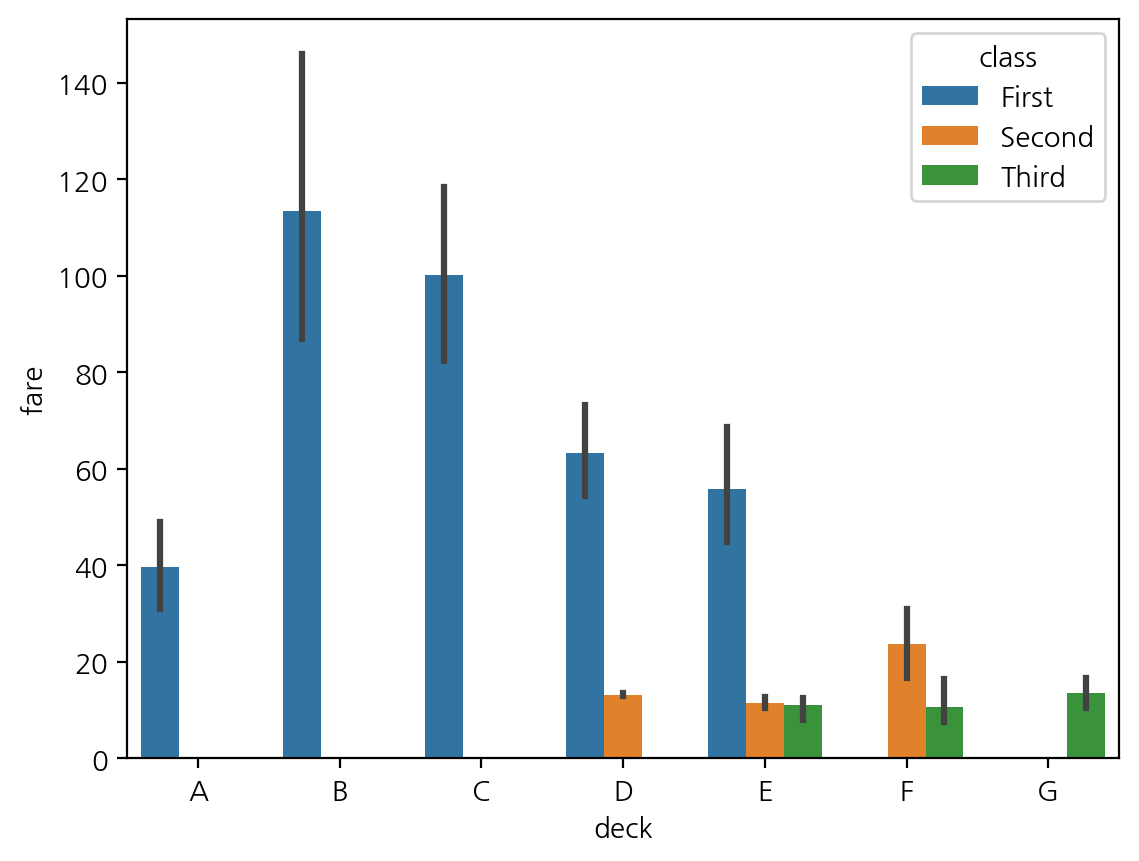

In [45]:
sns.barplot(ttn, x='deck', y='fare', hue='class')

##### 🔹 외부 파일 불러오기

In [46]:
# csv, 엑셀 파일 읽기
exam = pd.read_csv('./data/exam.csv')

pd.read_excel('./data/excel_exam.xlsx')

pd.read_excel('./data/excel_exam_novar.xlsx', header=None)

,0,1,2,3,4
0,1,1,50,98,50
1,2,1,60,97,60
2,3,2,25,80,65
3,4,2,50,89,98
4,5,3,20,98,15
5,6,3,50,98,45
6,7,4,46,98,65
7,8,4,48,87,12


In [47]:
exam

,id,nclass,math,english,science
0,1,1,50,98,50
1,2,1,60,97,60
2,3,1,45,86,78
3,4,1,30,98,58
4,5,2,25,80,65
5,6,2,50,89,98
6,7,2,80,90,45
7,8,2,90,78,25
8,9,3,20,98,15
9,10,3,50,98,45


##### 🔹 기본 통계 및 정보 확인

In [48]:
# df.describe()
# df.info()
# df.shape
# df.sum()
# df.mean()

##### 🔹 mpg 데이터 탐색

In [49]:
# 자동차 연비 데이터셋 분석
mpg = pd.read_csv('./data/mpg.csv')

mpg['category'].value_counts()

category
suv           62
compact       47
midsize       41
subcompact    35
pickup        33
minivan       11
2seater        5
Name: count, dtype: int64

In [50]:
mpg.describe()

,displ,year,cyl,cty,hwy
count,234.000000,234.000000,234.000000,234.000000,234.000000
mean,3.471795,2003.500000,5.888889,16.858974,23.440171
std,1.291959,4.509646,1.611534,4.255946,5.954643
min,1.600000,1999.000000,4.000000,9.000000,12.000000
25%,2.400000,1999.000000,4.000000,14.000000,18.000000
50%,3.300000,2003.500000,6.000000,17.000000,24.000000
75%,4.600000,2008.000000,8.000000,19.000000,27.000000
max,7.000000,2008.000000,8.000000,35.000000,44.000000


In [51]:
# 범주형 열 포함 요약
mpg.describe(include='all')

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category
count,234,234,234.000000,234.000000,234.000000,234,234,234.000000,234.000000,234,234
unique,15,38,NaN,NaN,NaN,10,3,NaN,NaN,5,7
top,dodge,caravan 2wd,NaN,NaN,NaN,auto(l4),f,NaN,NaN,r,suv
freq,37,11,NaN,NaN,NaN,83,106,NaN,NaN,168,62
mean,NaN,NaN,3.471795,2003.500000,5.888889,NaN,NaN,16.858974,23.440171,NaN,NaN
std,NaN,NaN,1.291959,4.509646,1.611534,NaN,NaN,4.255946,5.954643,NaN,NaN
min,NaN,NaN,1.600000,1999.000000,4.000000,NaN,NaN,9.000000,12.000000,NaN,NaN
25%,NaN,NaN,2.400000,1999.000000,4.000000,NaN,NaN,14.000000,18.000000,NaN,NaN
50%,NaN,NaN,3.300000,2003.500000,6.000000,NaN,NaN,17.000000,24.000000,NaN,NaN
75%,NaN,NaN,4.600000,2008.000000,8.000000,NaN,NaN,19.000000,27.000000,NaN,NaN


In [52]:
type(mpg)

pandas.core.frame.DataFrame

In [53]:
# 특정 열들만 describe()
mpg[['manufacturer', 'model', 'category']].describe()

,manufacturer,model,category
count,234,234,234
unique,15,38,7
top,dodge,caravan 2wd,suv
freq,37,11,62


##### 🔹 평균 계산 시 열 기준 명시

In [54]:
df = pd.DataFrame({'name' : ['김', '이', '박', '최'],
                    'english' : [90, 80, 60, 70], 
                    'math' : [50, 60, 90, 30]})

df

,name,english,math
0,김,90,50
1,이,80,60
2,박,60,90
3,최,70,30


In [55]:
# 모든 과목 평균 계산 (열 단위)
df.mean(axis='columns', numeric_only=True)

0    70.0
1    70.0
2    75.0
3    50.0
dtype: float64

##### ✅ 5주차: 파생 변수 생성과 조건 필터링

##### 🔹 파생 변수 생성 및 평균

In [56]:
df = pd.DataFrame({'var1' : [1, 2, 1],
                       'var2' : [2, 3, 2],
                       'var3' : [10, 20, 30]})
df

,var1,var2,var3
0,1,2,10
1,2,3,20
2,1,2,30


In [57]:
# 두 열의 합을 새로운 열로 생성
df['var_sum'] = df['var1'] + df['var2']
print(df, '\n')

# 두 열의 평균을 계산하여 새 열에 저장
df['var_mean'] = (df['var1'] + df['var2']) / 2
print(df, '\n')

# 각 행의 합과 평균 계산 (axis=1은 행 기준)
print(df.sum(axis=1), '\n')
print(df.mean(axis=1))

   var1  var2  var3  var_sum
0     1     2    10        3
1     2     3    20        5
2     1     2    30        3 

   var1  var2  var3  var_sum  var_mean
0     1     2    10        3       1.5
1     2     3    20        5       2.5
2     1     2    30        3       1.5 

0    17.5
1    32.5
2    37.5
dtype: float64 

0    3.5
1    6.5
2    7.5
dtype: float64


##### 🔹 연비 평균과 시각화

In [58]:
# 시내 연비(cty)와 고속도로 연비(hwy)의 평균으로 total 변수 생성
mpg['total'] = (mpg.cty + mpg.hwy) / 2

# cty, hwy의 평균을 mean()으로 계산하여 새 열 생성
mpg['mpg_mean'] = mpg[['cty', 'hwy']].mean(axis='columns')

mpg

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category,total,mpg_mean
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact,23.5,23.5
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact,25.0,25.0
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact,25.5,25.5
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact,25.5,25.5
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact,21.0,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize,23.5,23.5
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize,25.0,25.0
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize,21.0,21.0
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize,22.0,22.0


##### 🔹 조건 분류 (np.where)

In [59]:
# 연비가 20 이상이면 'pass', 아니면 'fail'
mpg['test'] = np.where(mpg.total >= 20, 'pass', 'fail')

# 연비에 따라 등급을 부여: 30 이상 A, 20 이상 B, 그 외 C
mpg['grade'] = np.where(mpg.total >= 30, 'A',
                np.where(mpg.total >= 20, 'B', 'C'))

# 더 세분화된 등급 분류
mpg['grade2'] = np.where(mpg.total >= 30, 'A',
                np.where(mpg.total >= 25, 'B',
                np.where(mpg.total >= 20, 'C', 'D')))

mpg

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,category,total,mpg_mean,test,grade,grade2
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact,23.5,23.5,pass,B,C
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact,25.0,25.0,pass,B,B
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact,25.5,25.5,pass,B,B
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact,25.5,25.5,pass,B,B
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact,21.0,21.0,pass,B,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize,23.5,23.5,pass,B,C
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize,25.0,25.0,pass,B,B
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize,21.0,21.0,pass,B,C
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize,22.0,22.0,pass,B,C


##### 🔹 조건 필터링, isin, query

In [60]:
exam.head()

,id,nclass,math,english,science
0,1,1,50,98,50
1,2,1,60,97,60
2,3,1,45,86,78
3,4,1,30,98,58
4,5,2,25,80,65


In [61]:
# nclass가 1, 3, 5 중 하나인 행만 필터링
exam.query('nclass in [1, 3, 5]')

,id,nclass,math,english,science
0,1,1,50,98,50
1,2,1,60,97,60
2,3,1,45,86,78
3,4,1,30,98,58
8,9,3,20,98,15
9,10,3,50,98,45
10,11,3,65,65,65
11,12,3,45,85,32
16,17,5,65,68,98
17,18,5,80,78,90


##### 🔹 열 참조 및 슬라이싱

In [62]:
# 열 이름 부분 슬라이싱
print(exam.columns[1:3])

# 열 슬라이싱으로 새로운 DataFrame 생성
print(exam[exam.columns[1:3]].head(), '\n')

exam[['nclass', 'math']].head()

Index(['nclass', 'math'], dtype='object')
   nclass  math
0       1    50
1       1    60
2       1    45
3       1    30
4       2    25 



,nclass,math
0,1,50
1,1,60
2,1,45
3,1,30
4,2,25


##### 🔹 열 삭제

In [63]:
# 'math', 'english' 열 제거
exam.drop(columns=['math', 'english'])

,id,nclass,science
0,1,1,50
1,2,1,60
2,3,1,78
3,4,1,58
4,5,2,65
5,6,2,98
6,7,2,45
7,8,2,25
8,9,3,15
9,10,3,45


##### 🔹 정렬

In [64]:
# nclass 기준 오름차순, math 기준 내림차순 정렬
exam.sort_values(['nclass', 'math'], ascending=[True, False])

,id,nclass,math,english,science
1,2,1,60,97,60
0,1,1,50,98,50
2,3,1,45,86,78
3,4,1,30,98,58
7,8,2,90,78,25
6,7,2,80,90,45
5,6,2,50,89,98
4,5,2,25,80,65
10,11,3,65,65,65
9,10,3,50,98,45


In [65]:
# 인덱스 기준 정렬 (내림차순 포함)
exam.sort_index(ascending=False)

,id,nclass,math,english,science
19,20,5,78,83,58
18,19,5,89,68,87
17,18,5,80,78,90
16,17,5,65,68,98
15,16,4,58,98,65
14,15,4,75,56,78
13,14,4,48,87,12
12,13,4,46,98,65
11,12,3,45,85,32
10,11,3,65,65,65


##### ✅ 6주차: 파생 변수 생성, 조건 분기, 그룹 요약, 데이터 결합

##### 🔹 데이터 불러오기

In [66]:
# exam.csv 파일을 읽어와 exam 데이터프레임 생성
import pandas as pd
import numpy as np

exam = pd.read_csv('data/exam.csv')
exam

,id,nclass,math,english,science
0,1,1,50,98,50
1,2,1,60,97,60
2,3,1,45,86,78
3,4,1,30,98,58
4,5,2,25,80,65
5,6,2,50,89,98
6,7,2,80,90,45
7,8,2,90,78,25
8,9,3,20,98,15
9,10,3,50,98,45


##### 🔹 head()로 상위 행 보기

In [67]:
exam.head(3)

,id,nclass,math,english,science
0,1,1,50,98,50
1,2,1,60,97,60
2,3,1,45,86,78


##### 🔹 assign() 함수로 새로운 열 생성

In [68]:
# assign()을 사용하여 총점(total)을 계산해 열로 추가
# 원본 exam 데이터에 영향이 없음 (새로운 데이터프레임을 반환)
exam.assign(total = exam['math'] + exam['english'] + exam['science'])

,id,nclass,math,english,science,total
0,1,1,50,98,50,198
1,2,1,60,97,60,217
2,3,1,45,86,78,209
3,4,1,30,98,58,186
4,5,2,25,80,65,170
5,6,2,50,89,98,237
6,7,2,80,90,45,215
7,8,2,90,78,25,193
8,9,3,20,98,15,133
9,10,3,50,98,45,193


##### 🔹 직접 열 추가

In [69]:
exam['total'] = exam['math'] + exam['english'] + exam['science']
exam

,id,nclass,math,english,science,total
0,1,1,50,98,50,198
1,2,1,60,97,60,217
2,3,1,45,86,78,209
3,4,1,30,98,58,186
4,5,2,25,80,65,170
5,6,2,50,89,98,237
6,7,2,80,90,45,215
7,8,2,90,78,25,193
8,9,3,20,98,15,133
9,10,3,50,98,45,193


##### 🔹 평균(mean) 열까지 함께 추가

In [70]:
exam.assign(
    total = exam['math'] + exam['english'] + exam['science'],
    mean = (exam['math'] + exam['english'] + exam['science']) / 3)

,id,nclass,math,english,science,total,mean
0,1,1,50,98,50,198,66.000000
1,2,1,60,97,60,217,72.333333
2,3,1,45,86,78,209,69.666667
3,4,1,30,98,58,186,62.000000
4,5,2,25,80,65,170,56.666667
5,6,2,50,89,98,237,79.000000
6,7,2,80,90,45,215,71.666667
7,8,2,90,78,25,193,64.333333
8,9,3,20,98,15,133,44.333333
9,10,3,50,98,45,193,64.333333


##### 🔹 조건에 따른 열 생성 (np.where)

In [71]:
# science 점수가 60점 이상이면 pass, 아니면 fail로 test 열 생성
exam.assign(test = np.where(exam.science >= 60, 'pass', 'fail'))

,id,nclass,math,english,science,total,test
0,1,1,50,98,50,198,fail
1,2,1,60,97,60,217,pass
2,3,1,45,86,78,209,pass
3,4,1,30,98,58,186,fail
4,5,2,25,80,65,170,pass
5,6,2,50,89,98,237,pass
6,7,2,80,90,45,215,fail
7,8,2,90,78,25,193,fail
8,9,3,20,98,15,133,fail
9,10,3,50,98,45,193,fail


##### 🔹 샘플링 (sample)

In [72]:
# 데이터의 30%만 랜덤으로 추출
# fraction(비율)
exam.sample(frac=0.3)

,id,nclass,math,english,science,total
5,6,2,50,89,98,237
11,12,3,45,85,32,162
0,1,1,50,98,50,198
18,19,5,89,68,87,244
2,3,1,45,86,78,209
16,17,5,65,68,98,231


##### 🔹 assign() + 정렬

In [73]:
# total 열을 추가한 후, total을 기준으로 오름차순 정렬
exam.assign(total = exam.math + exam.english + exam.science).sort_values('total')

# 내림차순 정렬
exam.assign(total = exam.math + exam.english + exam.science).sort_values('total', ascending=False)

,id,nclass,math,english,science,total
17,18,5,80,78,90,248
18,19,5,89,68,87,244
5,6,2,50,89,98,237
16,17,5,65,68,98,231
15,16,4,58,98,65,221
19,20,5,78,83,58,219
1,2,1,60,97,60,217
6,7,2,80,90,45,215
14,15,4,75,56,78,209
12,13,4,46,98,65,209


##### 🔹 lambda 함수 활용

In [74]:
# 간단한 람다 함수 사용 예
(lambda x, y : x + y)(30, 40)

70

In [75]:
f = lambda x, y : x + y
f(30, 4)

34

##### 🔹 assign + lambda 로 열 추가

In [76]:
# 람다로 total, mean 열 추가
exam.assign(
    total = lambda x : x.math + x.english + x.science,
    mean = lambda x : round(x.total / 3, 3))

,id,nclass,math,english,science,total,mean
0,1,1,50,98,50,198,66.000
1,2,1,60,97,60,217,72.333
2,3,1,45,86,78,209,69.667
3,4,1,30,98,58,186,62.000
4,5,2,25,80,65,170,56.667
5,6,2,50,89,98,237,79.000
6,7,2,80,90,45,215,71.667
7,8,2,90,78,25,193,64.333
8,9,3,20,98,15,133,44.333
9,10,3,50,98,45,193,64.333


##### 🔹 출력 소수점 자리 설정

In [77]:
# 소수점 둘째 자리까지 출력 설정
pd.set_option('display.precision', 2)

##### 🔹 집계 함수 (agg)와 describe

In [78]:
exam.describe()

,id,nclass,math,english,science,total
count,20.00,20.00,20.00,20.00,20.00,20.00
mean,10.50,3.00,57.45,84.90,59.45,201.80
std,5.92,1.45,20.30,12.88,25.29,30.80
min,1.00,1.00,20.00,56.00,12.00,133.00
25%,5.75,2.00,45.75,78.00,45.00,191.25
50%,10.50,3.00,54.00,86.50,62.50,209.00
75%,15.25,4.00,75.75,98.00,78.00,219.50
max,20.00,5.00,90.00,98.00,98.00,248.00


In [79]:
# aggregate (집합, 총계)
print(exam.agg(["mean", "max", "min", "median"]), '\n')

print(exam.agg(mean_math = ("math", "mean")))

          id  nclass   math  english  science  total
mean    10.5     3.0  57.45     84.9    59.45  201.8
max     20.0     5.0  90.00     98.0    98.00  248.0
min      1.0     1.0  20.00     56.0    12.00  133.0
median  10.5     3.0  54.00     86.5    62.50  209.0 

            math
mean_math  57.45


##### 🔹 다양한 agg() 축 예제

In [80]:
df = pd.DataFrame([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9],
                   [np.nan, np.nan, 10]], columns=['A', 'B', 'C'])

# 열 기준 집계 (axis=0 또는 생략 또는 'index')
print(df.agg(['sum', 'mean', 'median', 'min', 'max', 'count']), '\n')

# 행 기준 집계 (axis=1 또는 'columns')
df.agg(['sum', 'mean', 'median', 'min', 'max', 'count'], axis=1)

           A     B     C
sum     12.0  15.0  28.0
mean     4.0   5.0   7.0
median   4.0   5.0   7.5
min      1.0   2.0   3.0
max      7.0   8.0  10.0
count    3.0   3.0   4.0 



,sum,mean,median,min,max,count
0,6.0,2.0,2.0,1.0,3.0,3.0
1,15.0,5.0,5.0,4.0,6.0,3.0
2,24.0,8.0,8.0,7.0,9.0,3.0
3,10.0,10.0,10.0,10.0,10.0,1.0


##### 🔹 groupby() + agg 다양한 형태

In [81]:
exam

,id,nclass,math,english,science,total
0,1,1,50,98,50,198
1,2,1,60,97,60,217
2,3,1,45,86,78,209
3,4,1,30,98,58,186
4,5,2,25,80,65,170
5,6,2,50,89,98,237
6,7,2,80,90,45,215
7,8,2,90,78,25,193
8,9,3,20,98,15,133
9,10,3,50,98,45,193


In [82]:
# 단일 열 + 함수
print(exam.groupby('nclass').agg(mean_math = ('math', 'mean')), '\n')

# 다중 열 + 여러 함수
print(exam.groupby('nclass').agg({
    'math': ['mean', 'min', 'max'],
    'english': ['mean', 'median', 'max']}), '\n')

        mean_math
nclass           
1           46.25
2           61.25
3           45.00
4           56.75
5           78.00 

         math         english           
         mean min max    mean median max
nclass                                  
1       46.25  30  60   94.75   97.5  98
2       61.25  25  90   84.25   84.5  90
3       45.00  20  65   86.50   91.5  98
4       56.75  46  75   84.75   92.5  98
5       78.00  65  89   74.25   73.0  83 



In [83]:
# mean() 후 열 선택
print(exam.groupby('nclass').mean()[['math', 'english']], '\n')

# agg('mean')['math']
print(exam.groupby('nclass').agg('mean')['math'], '\n')

# 사전 형태로 열-함수 지정
exam.groupby('nclass').agg({'math': 'mean'})

         math  english
nclass                
1       46.25    94.75
2       61.25    84.25
3       45.00    86.50
4       56.75    84.75
5       78.00    74.25 

nclass
1    46.25
2    61.25
3    45.00
4    56.75
5    78.00
Name: math, dtype: float64 



,math
nclass,
1,46.25
2,61.25
3,45.00
4,56.75
5,78.00


##### 🔹 value_counts(), to_frame(), rename_axis()

In [84]:
# 시리즈 형태
mpg['drv'].value_counts()

drv
f    106
4    103
r     25
Name: count, dtype: int64

In [85]:
# to_frame(to DataFrame) : 데이터 프레임으로 변환
mpg['drv'].value_counts().to_frame('n').rename_axis('drive')

,n
drive,
f,106
4,103
r,25


##### 🔹 데이터 결합 (merge, concat)

#### 🔗 `pd.merge()`의 `how` 옵션 정리

| `how` 값     | 설명                                                              | 포함되는 행 기준            | 누락된 값 처리 |
|--------------|-------------------------------------------------------------------|-----------------------------|----------------|
| `'inner'`    | **공통 키 값만 병합**                                              | 교집합 (`df1 ∩ df2`)        | 제외됨         |
| `'outer'`    | **모든 키 값을 병합**                                              | 합집합 (`df1 ∪ df2`)        | `NaN`으로 채움 |
| `'left'`     | **왼쪽 데이터프레임(df1)의 키를 기준으로 병합**                   | 왼쪽 기준 (`df1`)           | 오른쪽은 `NaN` |
| `'right'`    | **오른쪽 데이터프레임(df2)의 키를 기준으로 병합**                 | 오른쪽 기준 (`df2`)         | 왼쪽은 `NaN`   |
| `'cross'`    | **모든 조합 (카테시안 곱)**                                        | 모든 행 × 모든 행 (`n × m`) | 없음           |

---

In [86]:
# 중간고사와 기말고사 데이터 병합
test1 = pd.DataFrame({'id': [1, 2, 3, 4, 5],
                      'midterm': [60, 80, 70, 90, 85]})

test2 = pd.DataFrame({'id': [1, 2, 3, 4, 5],
                      'final': [70, 83, 65, 95, 80]})

# 'id'를 기준으로 병합
# test1.merge(test2, on='id')
pd.merge(test1, test2, on='id')

,id,midterm,final
0,1,60,70
1,2,80,83
2,3,70,65
3,4,90,95
4,5,85,80


In [87]:
exam

,id,nclass,math,english,science,total
0,1,1,50,98,50,198
1,2,1,60,97,60,217
2,3,1,45,86,78,209
3,4,1,30,98,58,186
4,5,2,25,80,65,170
5,6,2,50,89,98,237
6,7,2,80,90,45,215
7,8,2,90,78,25,193
8,9,3,20,98,15,133
9,10,3,50,98,45,193


In [88]:
# 반 정보 추가 병합
name = pd.DataFrame({'nclass': [1, 2, 3, 4, 5],
                     'teacher': ['kim', 'lee', 'park', 'choi', 'jung']})

# 'nclass'를 기준으로 inner(공통된 부분) 병합
pd.merge(exam, name, on='nclass', how='inner')

,id,nclass,math,english,science,total,teacher
0,1,1,50,98,50,198,kim
1,2,1,60,97,60,217,kim
2,3,1,45,86,78,209,kim
3,4,1,30,98,58,186,kim
4,5,2,25,80,65,170,lee
5,6,2,50,89,98,237,lee
6,7,2,80,90,45,215,lee
7,8,2,90,78,25,193,lee
8,9,3,20,98,15,133,park
9,10,3,50,98,45,193,park


In [89]:
# 데이터 행 결합 (concat)
group_a = pd.DataFrame({'id': [1, 2, 3, 4, 5],
                        'test': [60, 80, 70, 90, 85]})

group_b = pd.DataFrame({'id': [6, 7, 8, 9, 10],
                        'test': [70, 83, 65, 95, 80]})

print(pd.concat([group_a, group_b]), '\n')

# ignore_index : 기존 인덱스 무시 여부 (새 인덱스 생성)
# pd.concat([group_a, group_b]).reset_index(drop=True)
pd.concat([group_a, group_b], ignore_index=True)

   id  test
0   1    60
1   2    80
2   3    70
3   4    90
4   5    85
0   6    70
1   7    83
2   8    65
3   9    95
4  10    80 



,id,test
0,1,60
1,2,80
2,3,70
3,4,90
4,5,85
5,6,70
6,7,83
7,8,65
8,9,95
9,10,80


##### ✅ 7주차: 데이터 정제 및 결측값 처리

##### 🔹 데이터 불러오기

In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt

# 예제 DataFrame 생성
df = pd.DataFrame({'sex': ["M", 'F', np.nan, 'M', 'F'],
                   'score': [5, 4, 3, 4, None]})

# Titanic 데이터셋 불러오기
tdf = sns.load_dataset('titanic')

##### 🔹 결측값 확인 함수 (isna / isnull / notna / notnull)

In [91]:
# DataFrame 전체 결측값 확인

# pd.isna(df)
print(df.isna())

# pd.isnull(df)
df.isnull()

     sex  score
0  False  False
1  False  False
2   True  False
3  False  False
4  False   True


,sex,score
0,False,False
1,False,False
2,True,False
3,False,False
4,False,True


In [92]:
# 결측값이 아닌 값 확인

# pd.notna(df)
print(df.notna())

# pd.notnull(df)
df.notnull()

     sex  score
0   True   True
1   True   True
2  False   True
3   True   True
4   True  False


,sex,score
0,True,True
1,True,True
2,False,True
3,True,True
4,True,False


##### 🔹 결측값 개수 확인 (sum)

In [93]:
df

,sex,score
0,M,5.0
1,F,4.0
2,NaN,3.0
3,M,4.0
4,F,NaN


In [94]:
# 열 기준 결측값 개수
df.isna().sum()

sex      1
score    1
dtype: int64

In [95]:
# 행 기준 결측값 개수
df.isna().sum(axis=1)

0    0
1    0
2    1
3    0
4    1
dtype: int64

##### 🔹 결측값 존재 여부 확인 (any / all)

In [96]:
# 열 기준, 하나라도 결측값이 있는지
df.isna().any()

sex      True
score    True
dtype: bool

In [97]:
# 행 기준, 모두 결측값인지
df.isna().all(axis=1)

0    False
1    False
2    False
3    False
4    False
dtype: bool

In [98]:
# 불리언 반전 사용 예시
# 결측값이 없는(~) 행 추출
df[~df.isna().any(axis=1)]

,sex,score
0,M,5.0
1,F,4.0
3,M,4.0


##### 🔹 특정 조건 필터링

In [99]:
# 결측값이 하나 이상 있는 행
df[df.isna().any(axis=1)]

,sex,score
2,NaN,3.0
4,F,NaN


In [100]:
# 결측값이 없는 행
df[~df.isna().any(axis=1)]

,sex,score
0,M,5.0
1,F,4.0
3,M,4.0


In [101]:
# 결측값이 1개인 행
tdf[tdf.isna().sum(axis=1) == 1]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
2,1,3,female,26.0,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
4,0,3,male,35.0,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True
7,0,3,male,2.0,3,1,21.07,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.13,S,Third,woman,False,NaN,Southampton,yes,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
883,0,2,male,28.0,0,0,10.50,S,Second,man,True,NaN,Southampton,no,True
884,0,3,male,25.0,0,0,7.05,S,Third,man,True,NaN,Southampton,no,True
885,0,3,female,39.0,0,5,29.12,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True


In [102]:
# 여러 열에서 동시에 결측값 조건
tdf[(tdf.age.isna()) & (tdf.deck.isna())]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
5,0,3,male,NaN,0,0,8.46,Q,Third,man,True,NaN,Queenstown,no,True
17,1,2,male,NaN,0,0,13.00,S,Second,man,True,NaN,Southampton,yes,True
19,1,3,female,NaN,0,0,7.22,C,Third,woman,False,NaN,Cherbourg,yes,True
26,0,3,male,NaN,0,0,7.22,C,Third,man,True,NaN,Cherbourg,no,True
28,1,3,female,NaN,0,0,7.88,Q,Third,woman,False,NaN,Queenstown,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,0,3,male,NaN,0,0,7.23,C,Third,man,True,NaN,Cherbourg,no,True
863,0,3,female,NaN,8,2,69.55,S,Third,woman,False,NaN,Southampton,no,False
868,0,3,male,NaN,0,0,9.50,S,Third,man,True,NaN,Southampton,no,True
878,0,3,male,NaN,0,0,7.90,S,Third,man,True,NaN,Southampton,no,True


In [103]:
tdf[(tdf.age.isna()) & (tdf.deck.isna()) & (tdf.embark_town.isna())]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone


##### 🔹 Seaborn을 활용한 결측값 시각화

<Axes: >

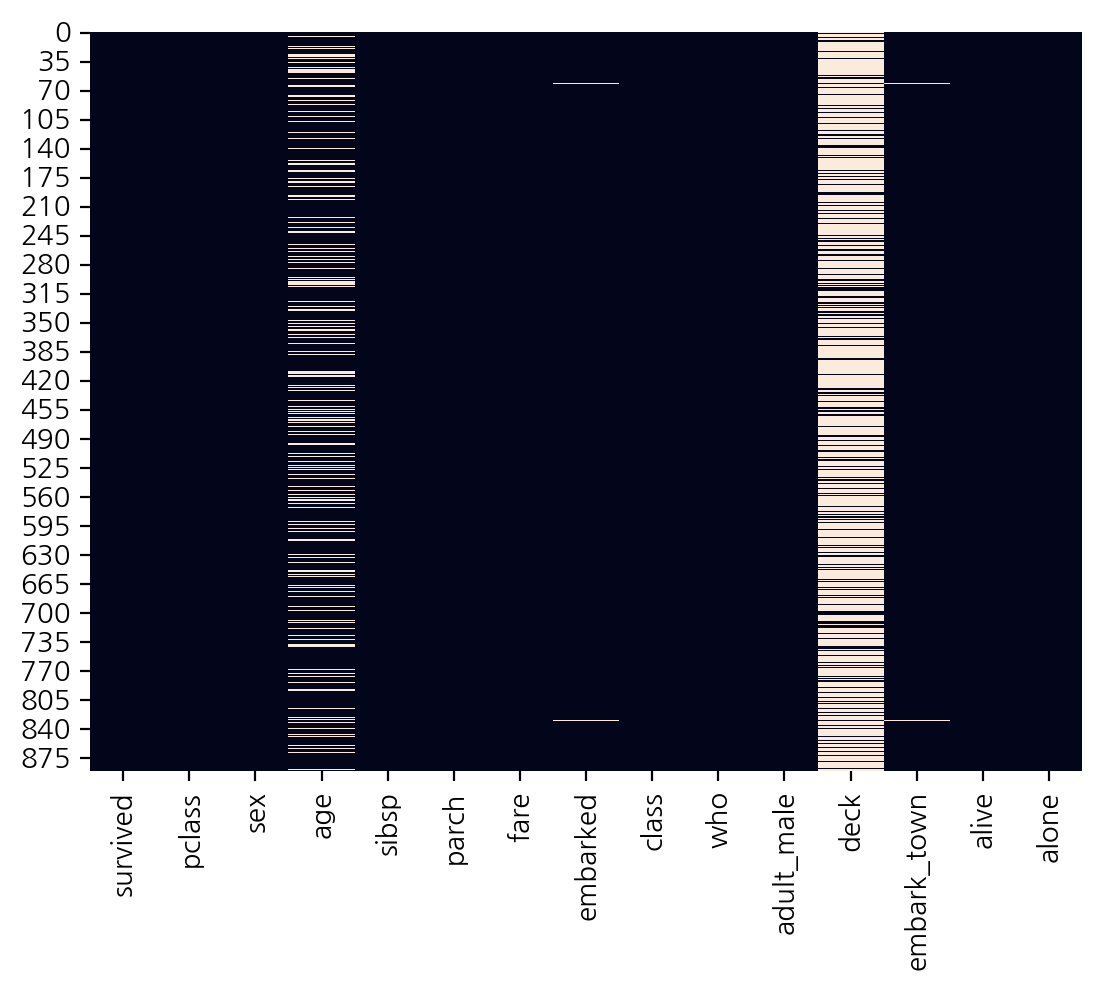

In [104]:
sns.heatmap(df.isnull(), cbar=False)
sns.heatmap(tdf.isnull(), cbar=False)

##### 🔹 Missingno 라이브러리를 활용한 시각화

<Axes: >

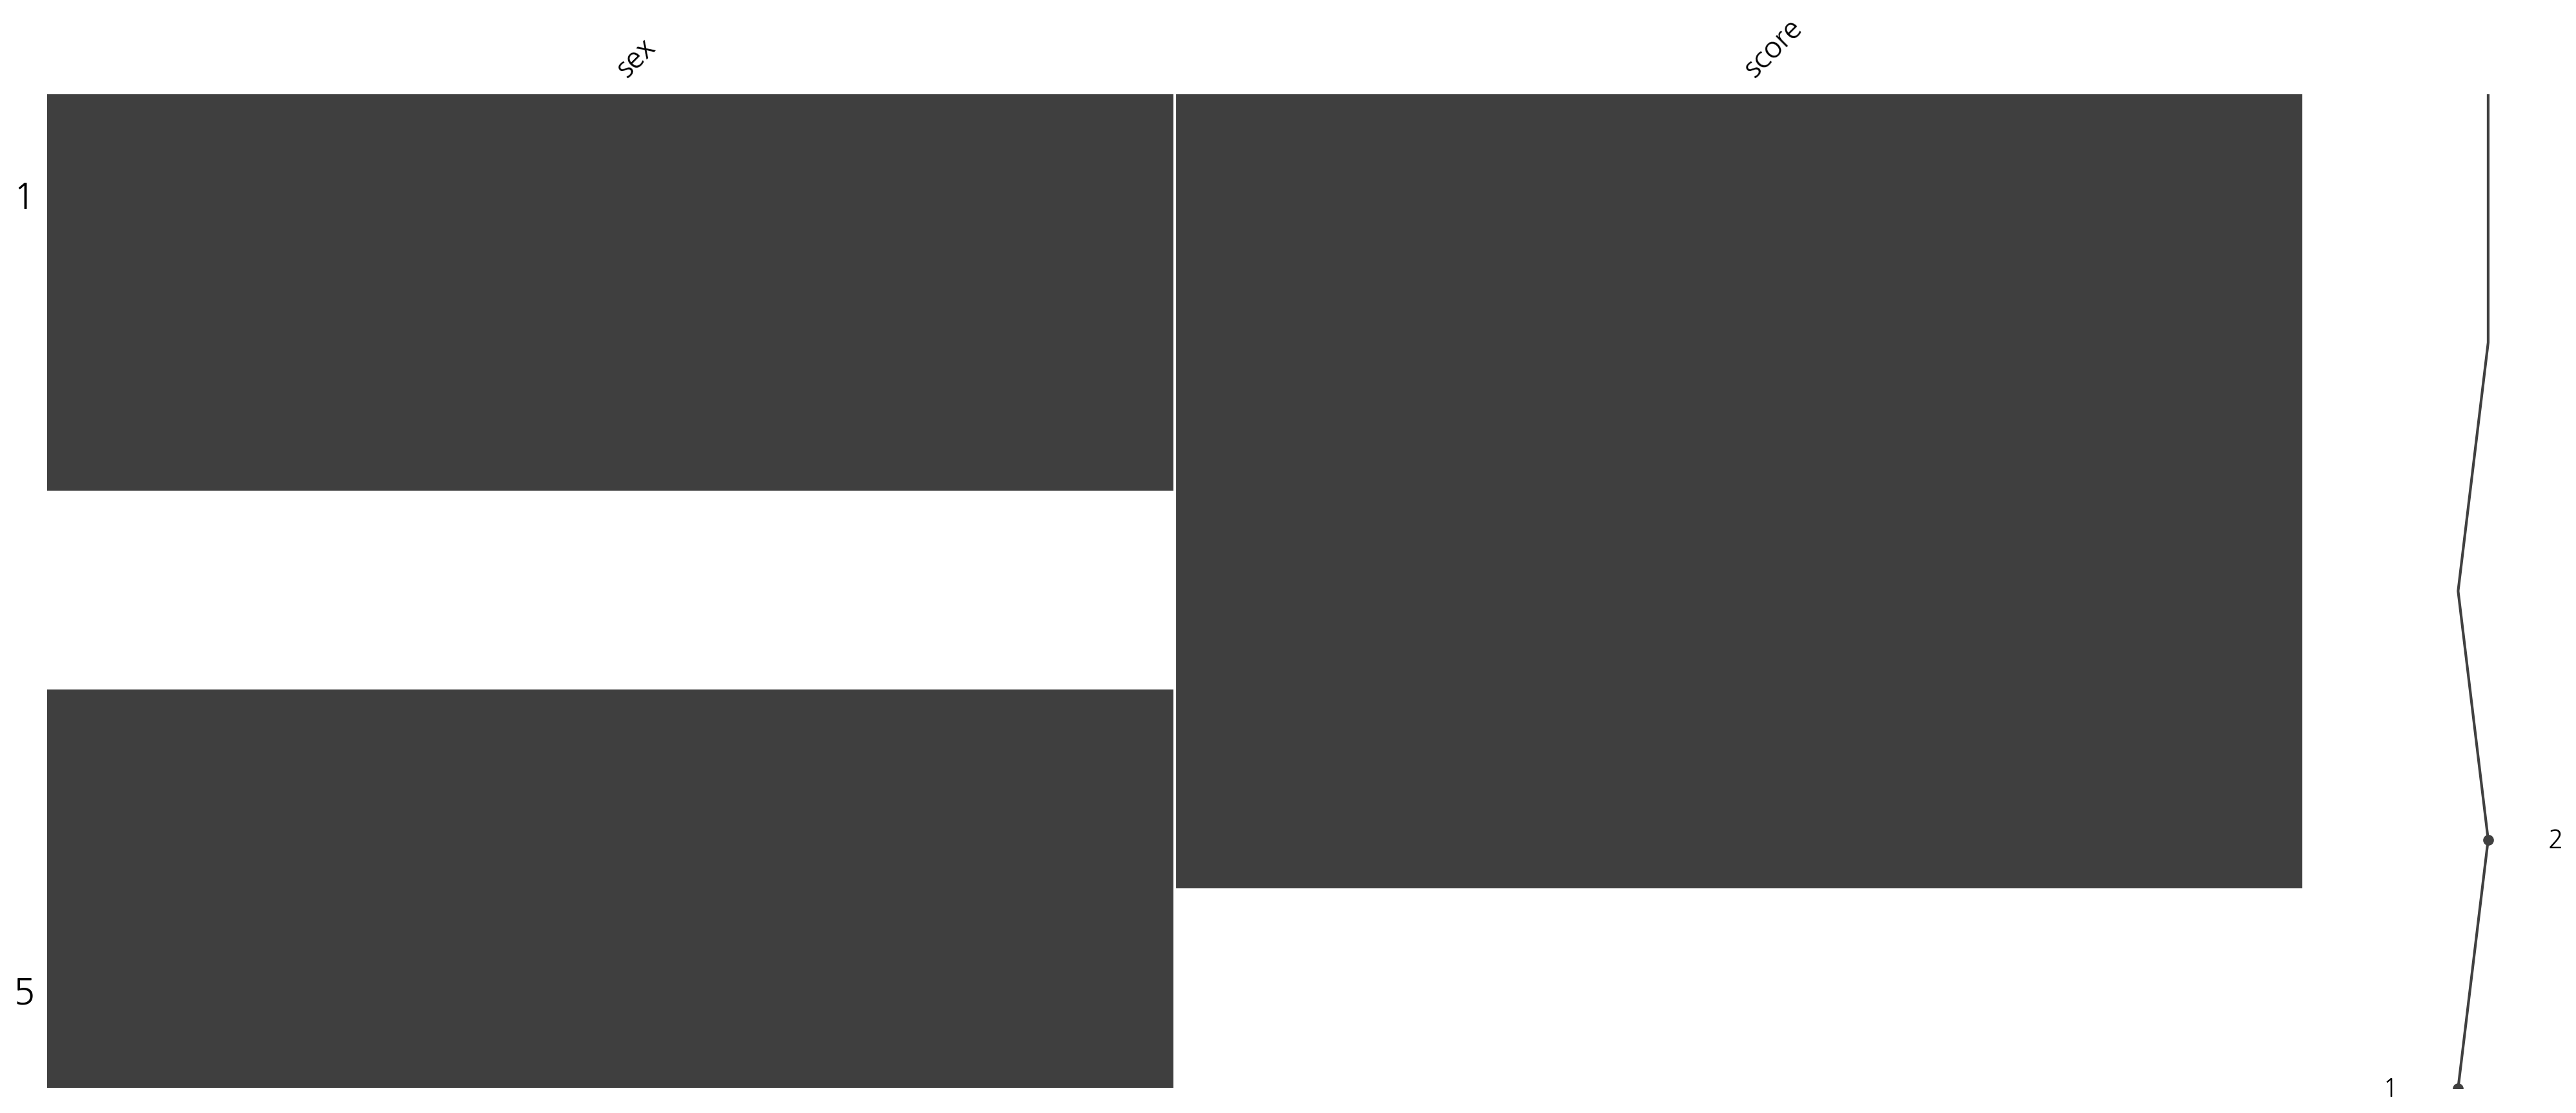

In [105]:
msno.matrix(df)

<Axes: >

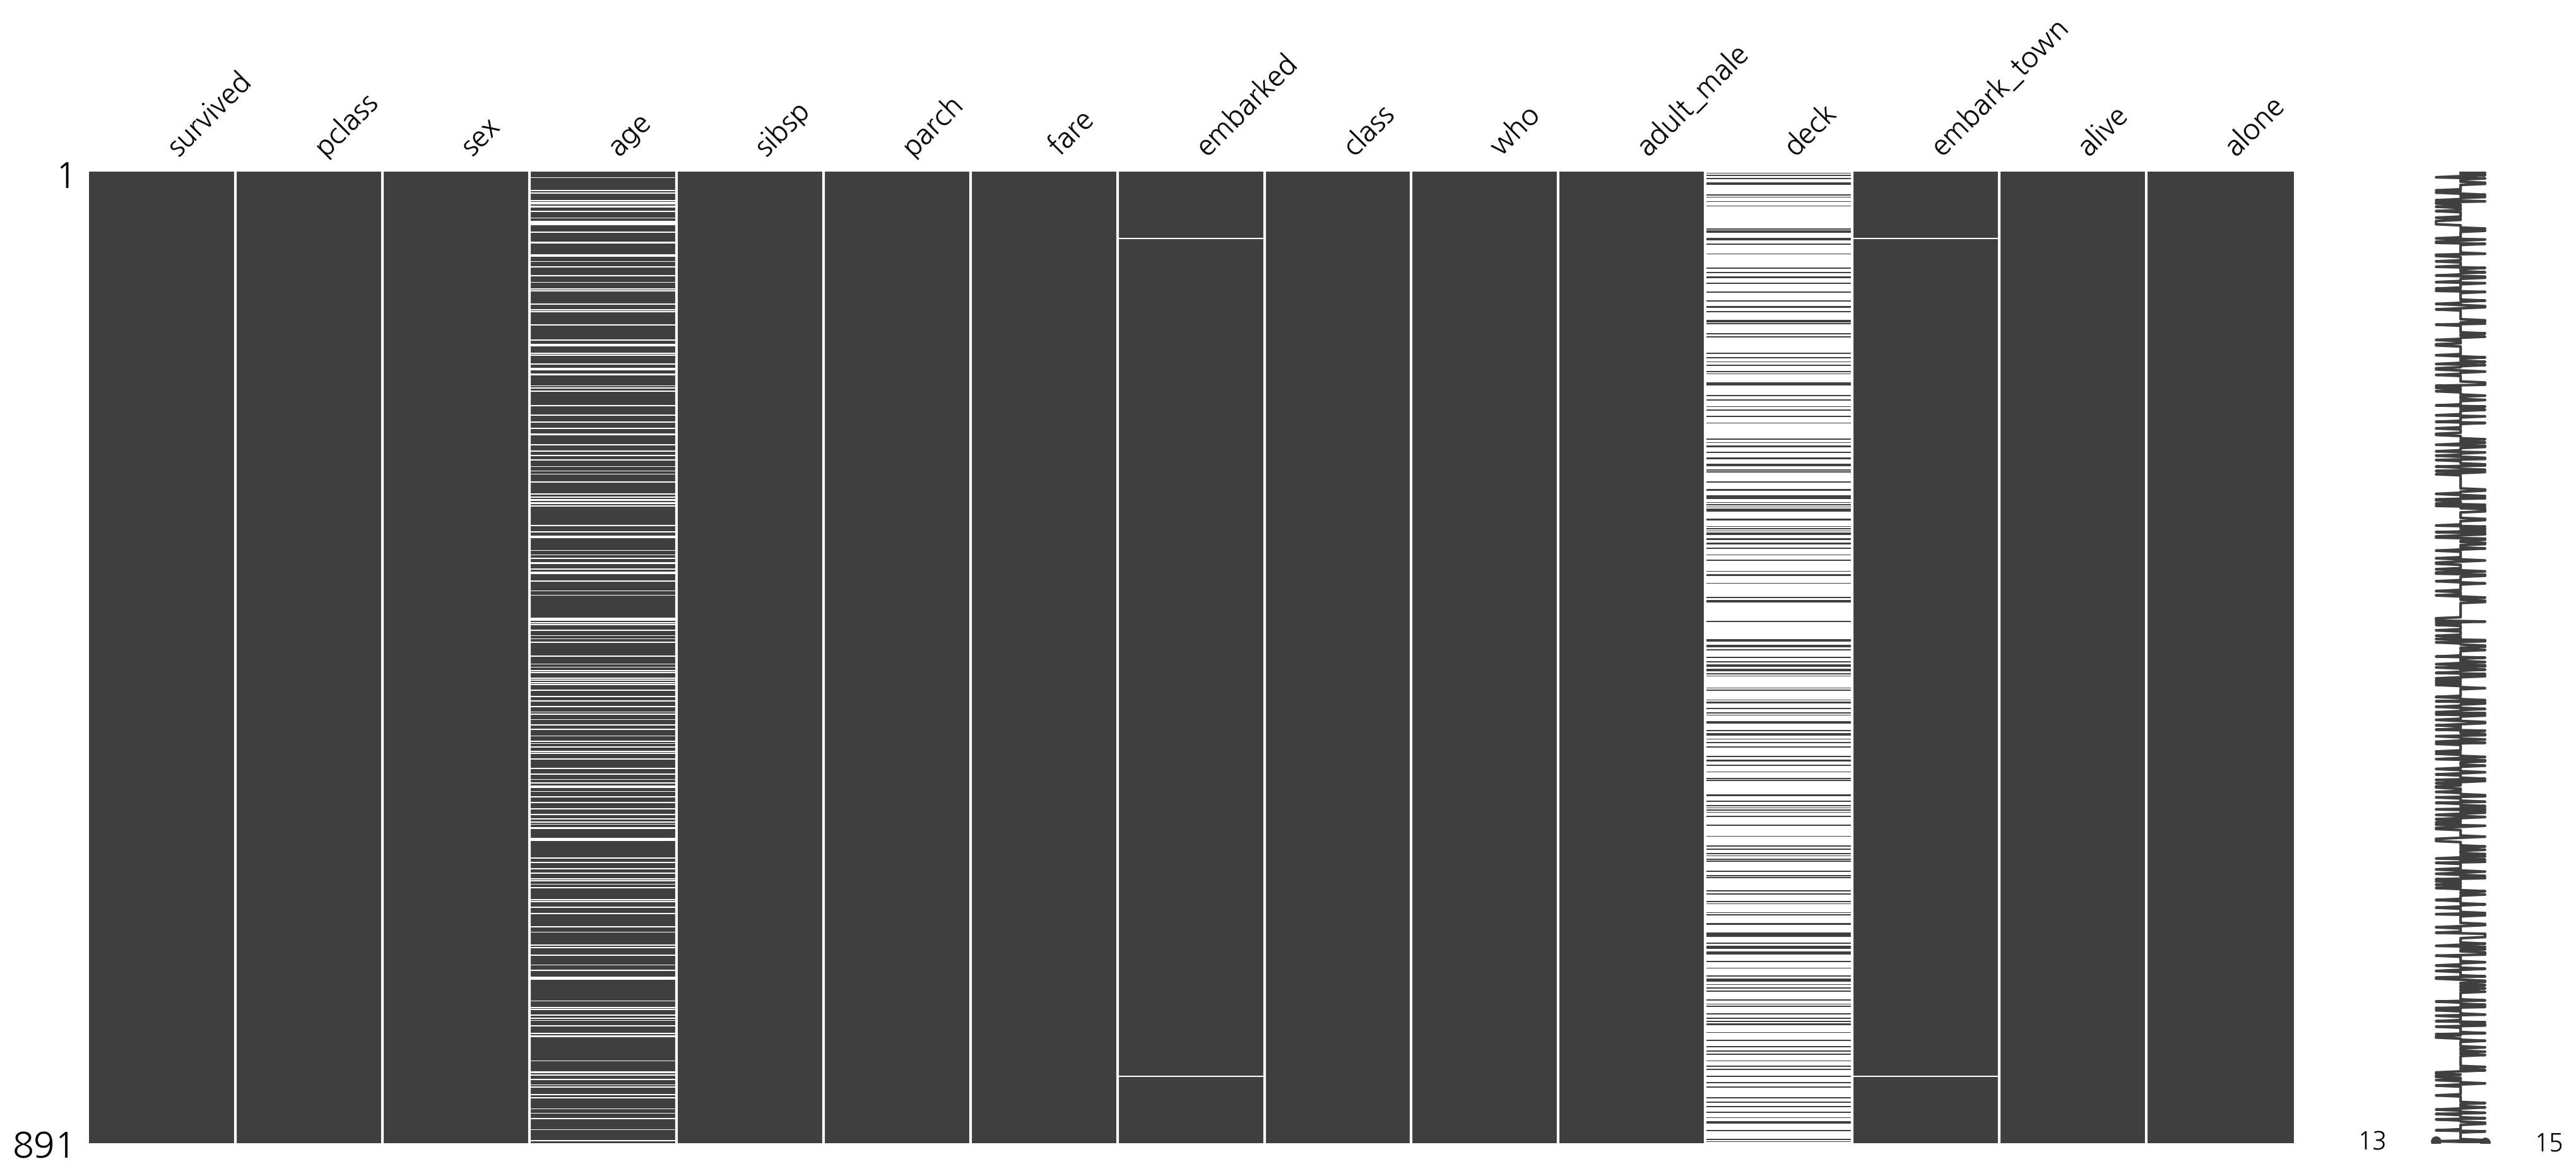

In [106]:
msno.matrix(tdf)

<Axes: >

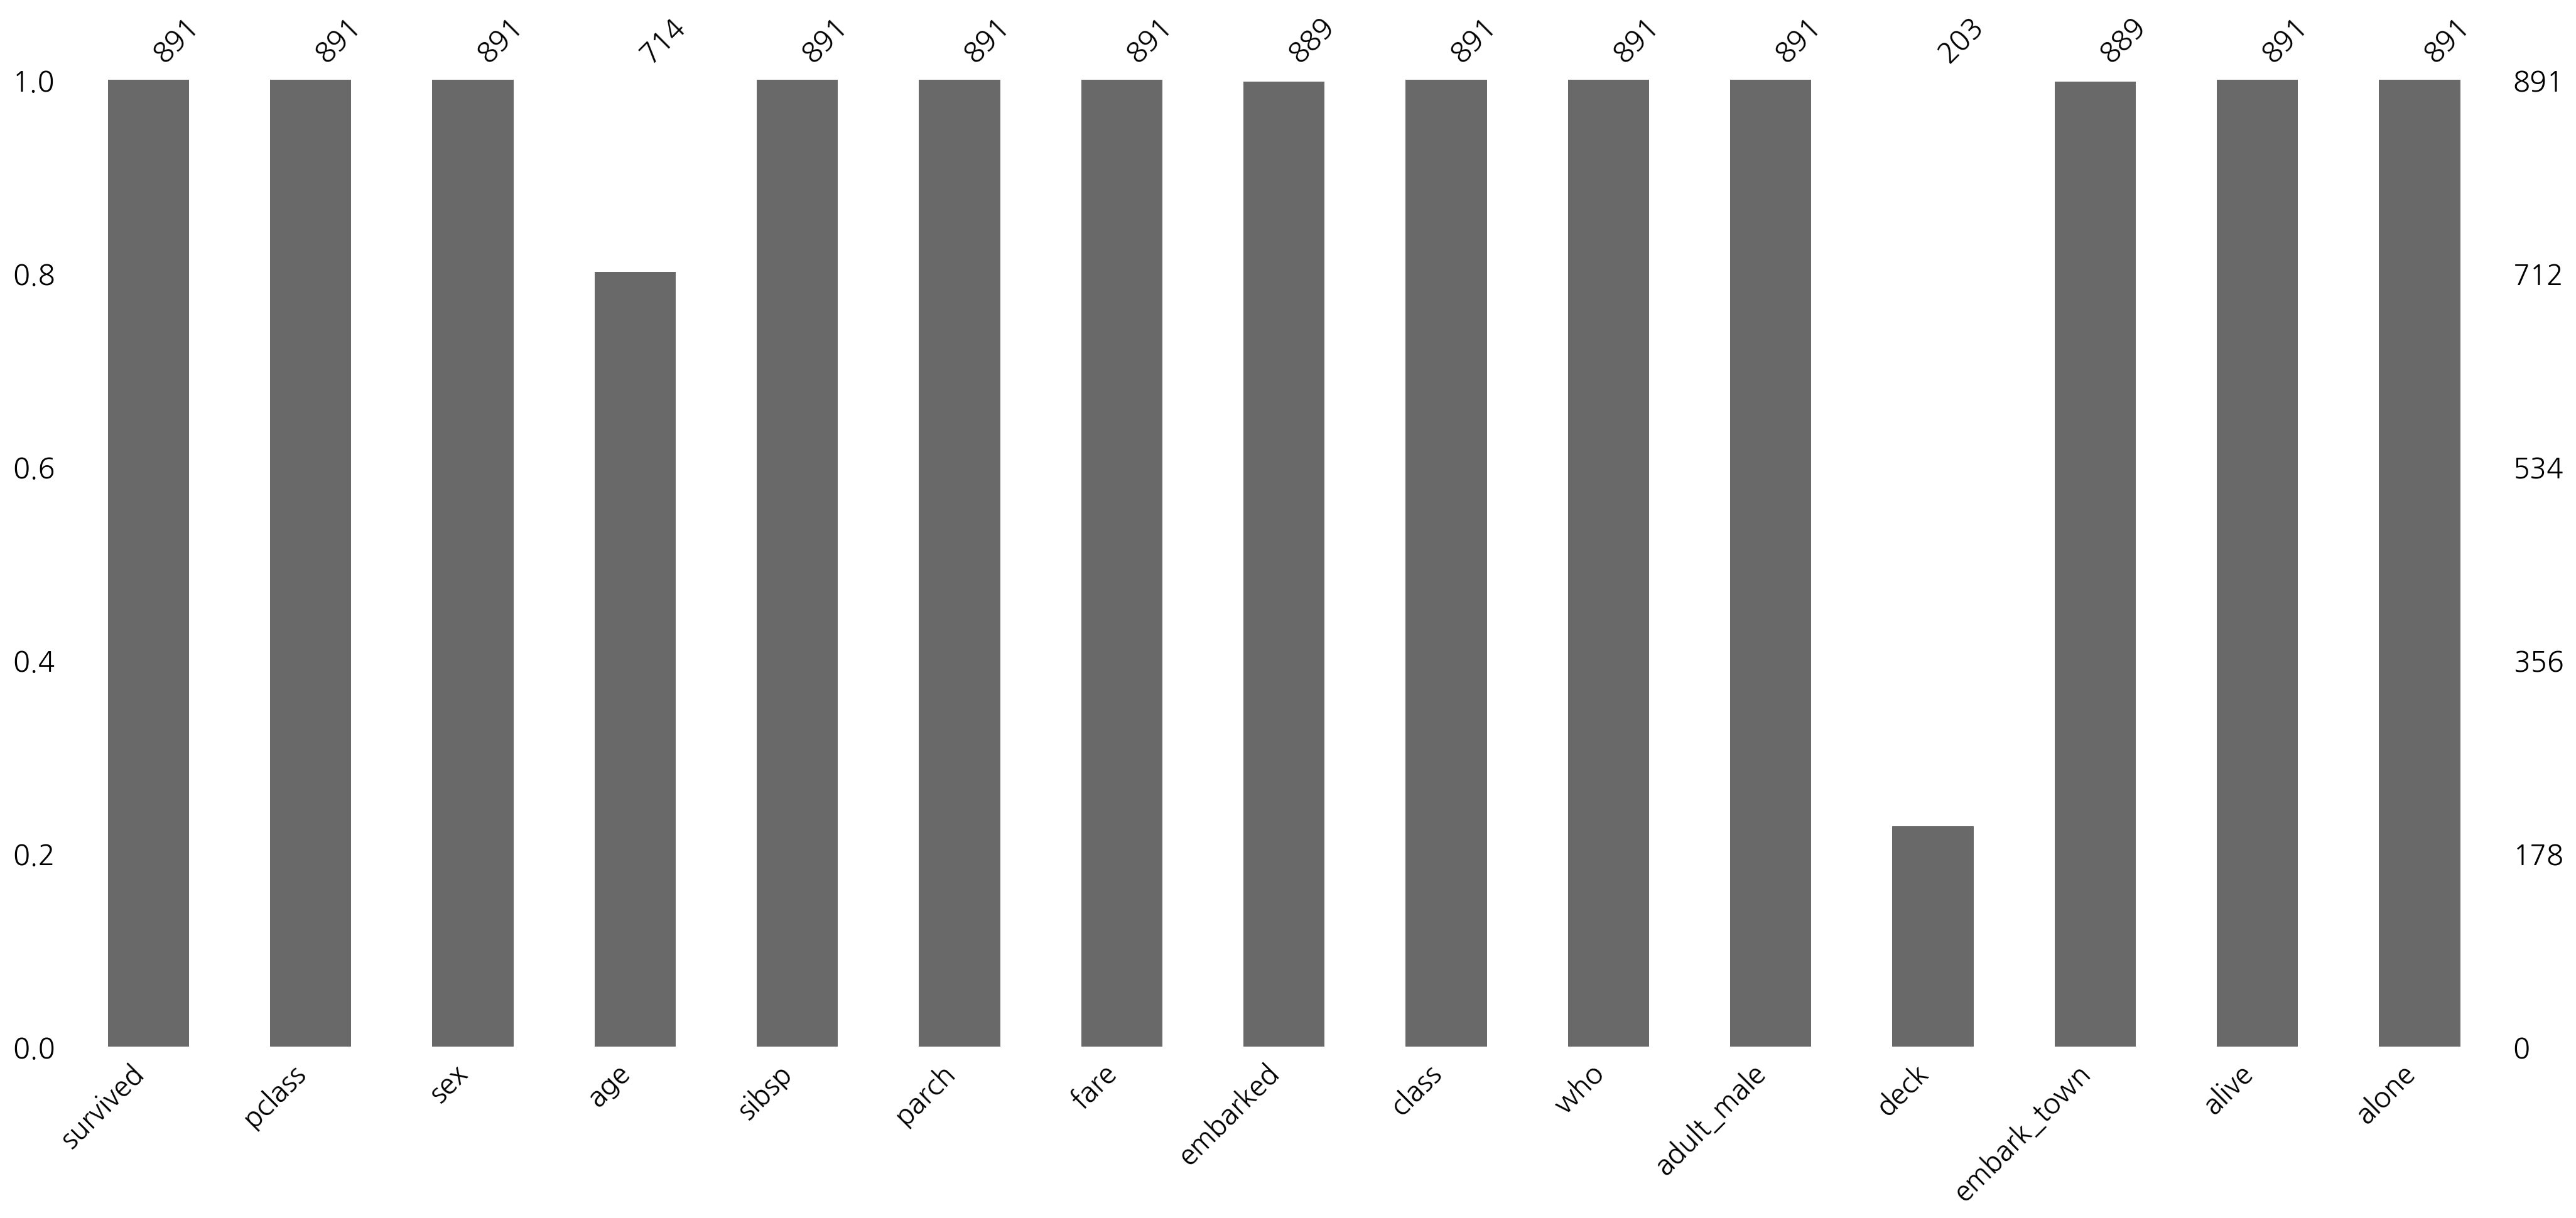

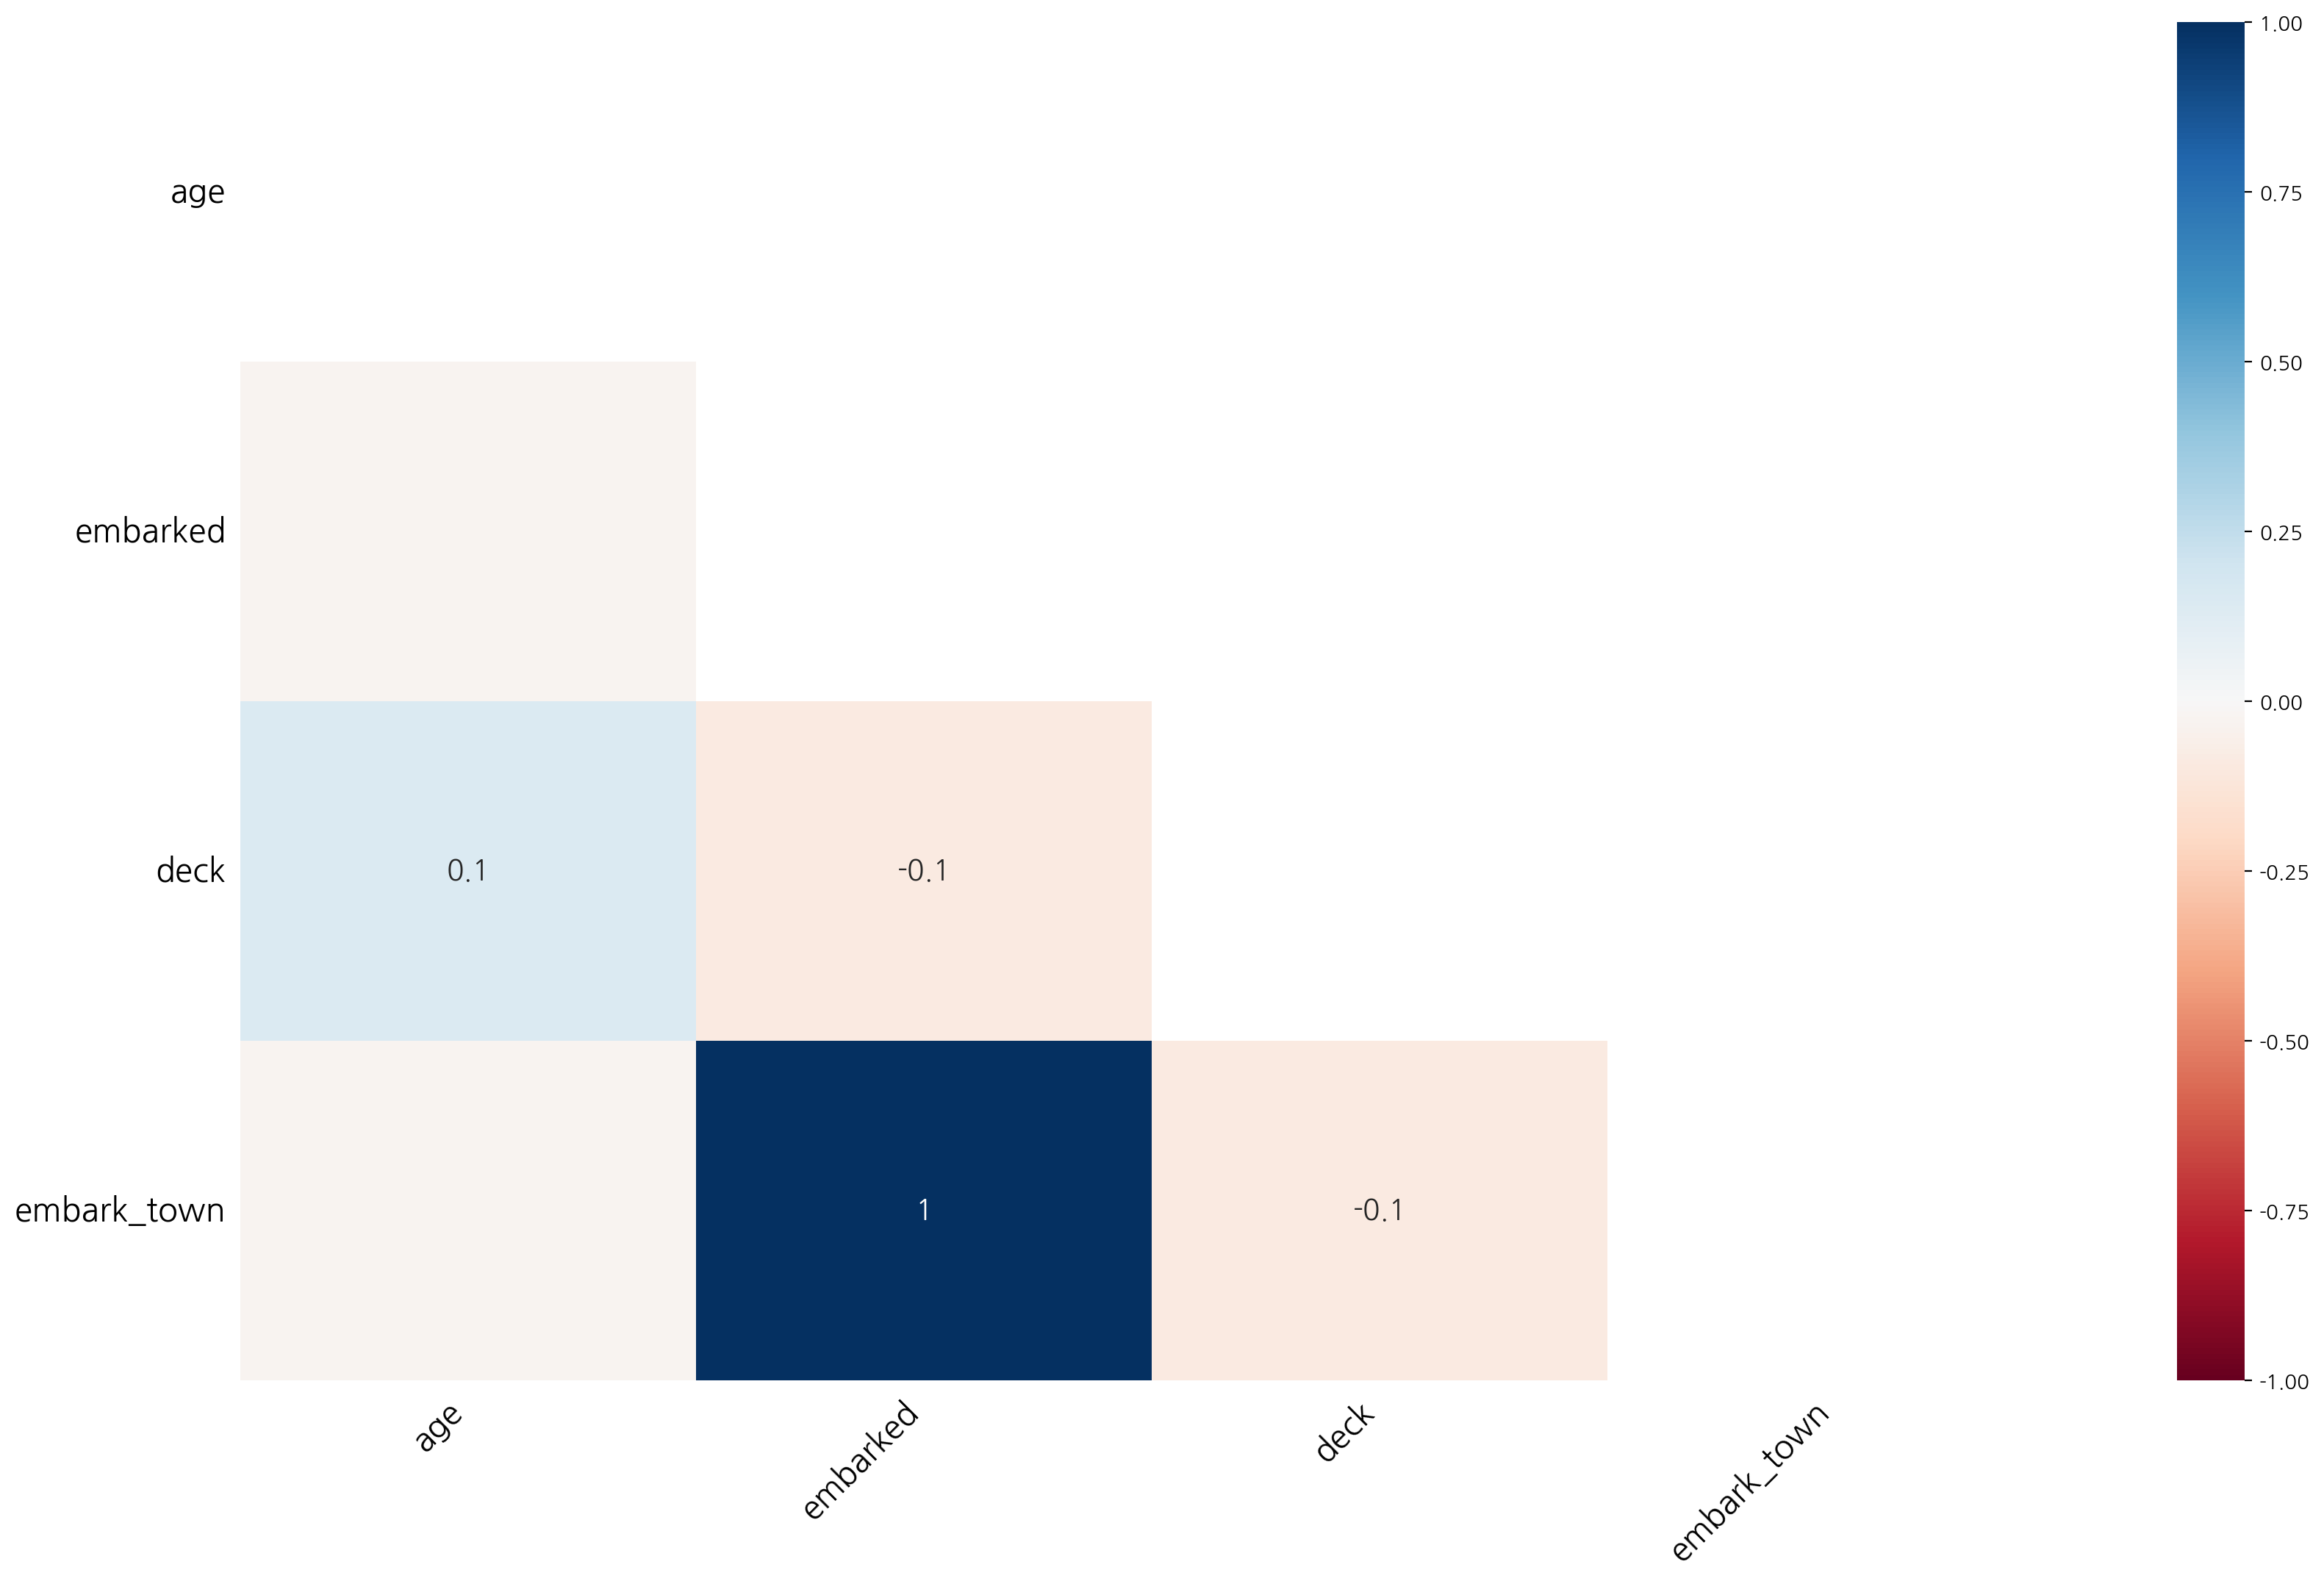

In [107]:
# 결측값 개수 막대그래프
msno.bar(tdf)

# 결측값 간 상관관계
msno.heatmap(tdf)

##### 🔹 불리언 Series 연산

In [108]:
s = pd.Series([True, False, True])

print(s.sum())    # True의 개수
print(s.any())    # 하나라도 True면 True
print(s.all())    # 모두 True면 True

2
True
False


##### 🔹 DataFrame 샘플링 및 정보 확인

In [109]:
# 무작위로 20개 샘플링
tdf2 = tdf.sample(20)

# DataFrame 구조 및 결측값 포함 정보 확인
tdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


##### 빠진 함수들

In [110]:
# 예제용 데이터 생성
df = pd.DataFrame({
    'col': [1, 2, 3, 4, 3, 2, 5],
    'col2': [1, 2, np.nan, 4, np.nan, 6, np.nan],
    'A': [10, 20, 30, 40, 50, 60, 70],
    'B': ['x', 'y', 'z', 'x', 'y', 'z', 'x']
})
df2 = pd.DataFrame({
    'col': [8, 9],
    'A': [80, 90],
    'B': ['y', 'z']
})

# Numpy 배열 관련 예제
arr = np.arange(10)

# 히스토그램/바 그래프용 데이터
data = np.random.randn(100)

In [111]:
pd.Categorical(['low', 'medium', 'high', 'medium', 'low'])

['low', 'medium', 'high', 'medium', 'low']
Categories (3, object): ['high', 'low', 'medium']

In [112]:
pd.Timestamp('2025-01-01')

Timestamp('2025-01-01 00:00:00')

In [113]:
pd.date_range(start='2023-01-01', periods=5)

DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05'],
              dtype='datetime64[ns]', freq='D')

In [114]:
df['col']

0    1
1    2
2    3
3    4
4    3
5    2
6    5
Name: col, dtype: int64

In [115]:
df['col'] = df['col'].astype('float')

df['col']

0    1.0
1    2.0
2    3.0
3    4.0
4    3.0
5    2.0
6    5.0
Name: col, dtype: float64

In [116]:
print(np.array([1, 2, 3]), '\n')

print(np.arange(0, 10, 2), '\n')

print(np.linspace(0, 1, 5), '\n')

print(np.ones((3, 3)), '\n')

[1 2 3] 

[0 2 4 6 8] 

[0.   0.25 0.5  0.75 1.  ] 

[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]] 



In [117]:
print(arr)

arr.reshape(2, 5)

[0 1 2 3 4 5 6 7 8 9]


array([[0, 1, 2, 3, 4],
       [5, 6, 7, 8, 9]])

In [118]:
df

,col,col2,A,B
0,1.0,1.0,10,x
1,2.0,2.0,20,y
2,3.0,NaN,30,z
3,4.0,4.0,40,x
4,3.0,NaN,50,y
5,2.0,6.0,60,z
6,5.0,NaN,70,x


In [119]:
df.rename(columns={'A':'a'})

,col,col2,a,B
0,1.0,1.0,10,x
1,2.0,2.0,20,y
2,3.0,NaN,30,z
3,4.0,4.0,40,x
4,3.0,NaN,50,y
5,2.0,6.0,60,z
6,5.0,NaN,70,x


In [120]:
print(sorted([3, 1, 2]),'\n')

# df.to_csv('output.csv')

print(df['col'].unique(),'\n')

print(df['col'].nunique(),'\n')

[1, 2, 3] 

[1. 2. 3. 4. 5.] 

5 



In [121]:
print(df['col2'].isnull(),'\n')

# ffill : front fill
print(df.fillna(method='ffill'),'\n')

print(df['col2'].min(),'\n')

print(df['col2'].median(),'\n')

df.tail(3)

0    False
1    False
2     True
3    False
4     True
5    False
6     True
Name: col2, dtype: bool 

   col  col2   A  B
0  1.0   1.0  10  x
1  2.0   2.0  20  y
2  3.0   2.0  30  z
3  4.0   4.0  40  x
4  3.0   4.0  50  y
5  2.0   6.0  60  z
6  5.0   6.0  70  x 

1.0 

3.0 



C:\Users\asus\AppData\Local\Temp\ipykernel_16208\4234334982.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  print(df.fillna(method='ffill'),'\n')


,col,col2,A,B
4,3.0,NaN,50,y
5,2.0,6.0,60,z
6,5.0,NaN,70,x


In [122]:
print(np.random.random(3),'\n')
print(np.random.randint(0, 10, 5),'\n')
print(np.random.randn(3))

[0.463439   0.03315751 0.70334589] 

[0 4 6 5 9] 

[ 0.82365215 -1.10487696  1.03630743]


<BarContainer object of 2 artists>

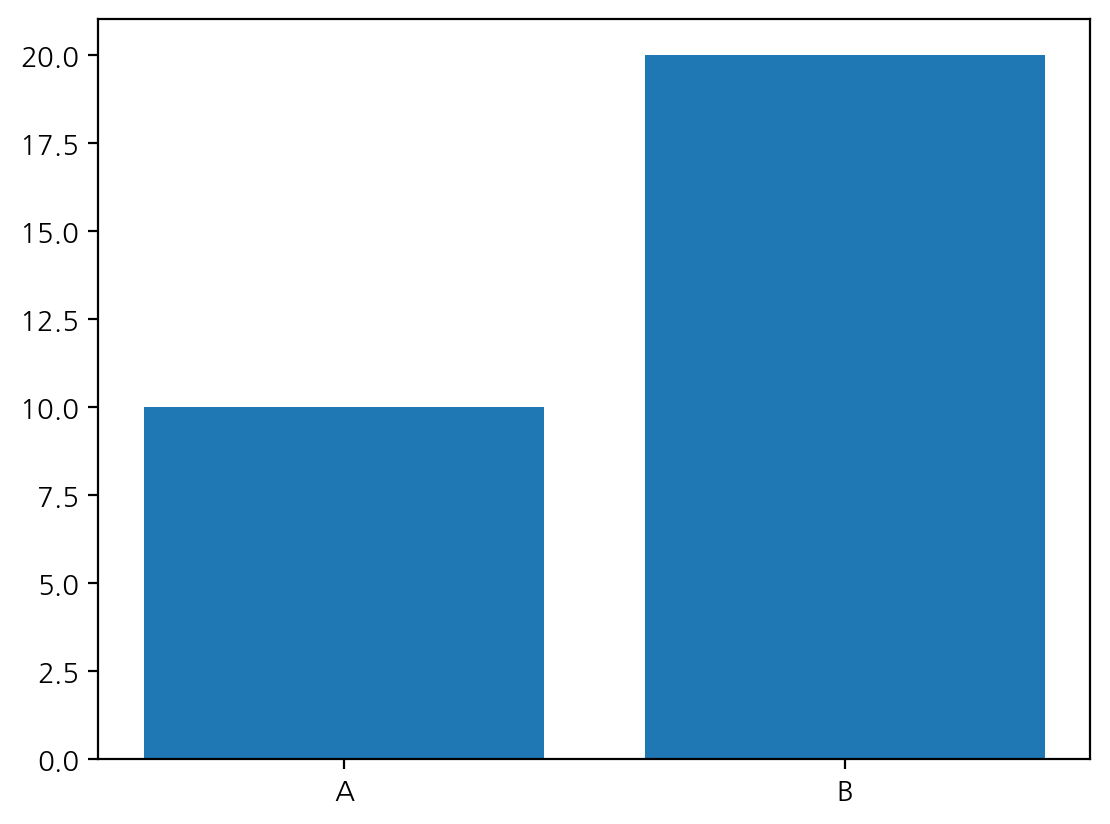

In [123]:
plt.bar(['A', 'B'], [10, 20])

(array([ 3.,  7.,  9., 12., 11., 15., 17., 11.,  9.,  6.]),
 array([-2.07134785, -1.67269709, -1.27404633, -0.87539557, -0.47674481,
        -0.07809405,  0.32055671,  0.71920747,  1.11785824,  1.516509  ,
         1.91515976]),
 <BarContainer object of 10 artists>)

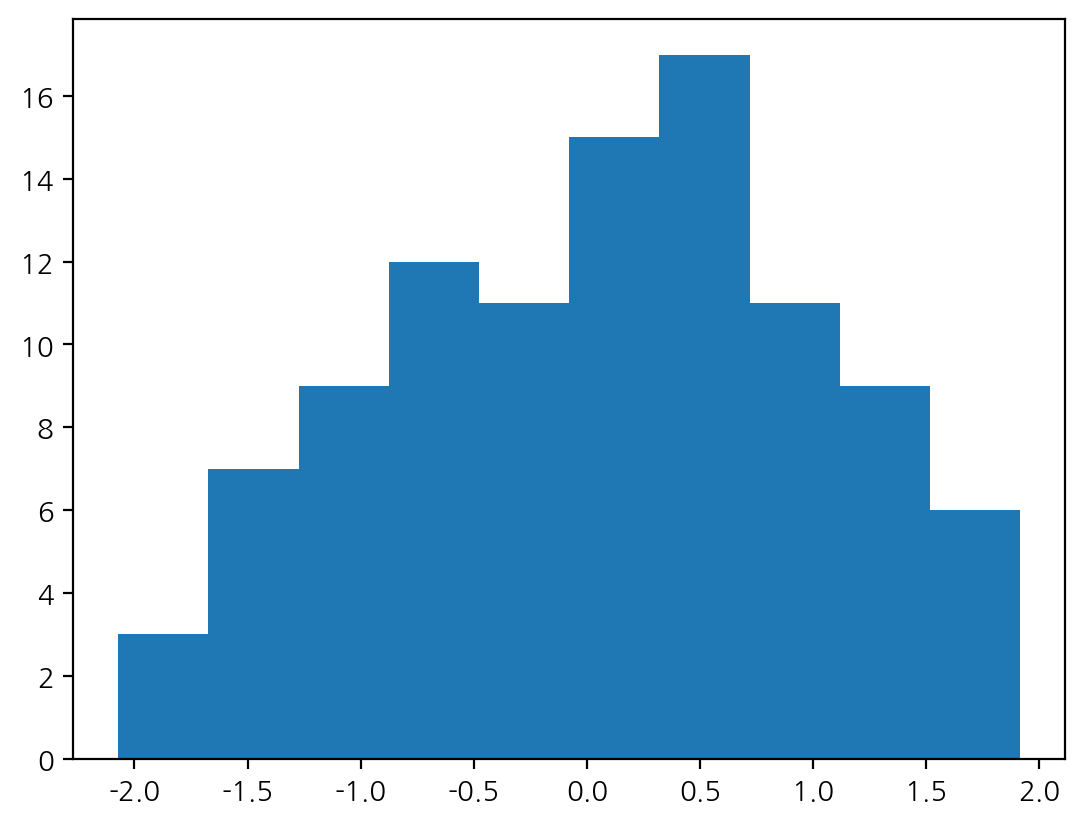

In [124]:
plt.hist(data)

<Axes: ylabel='Count'>

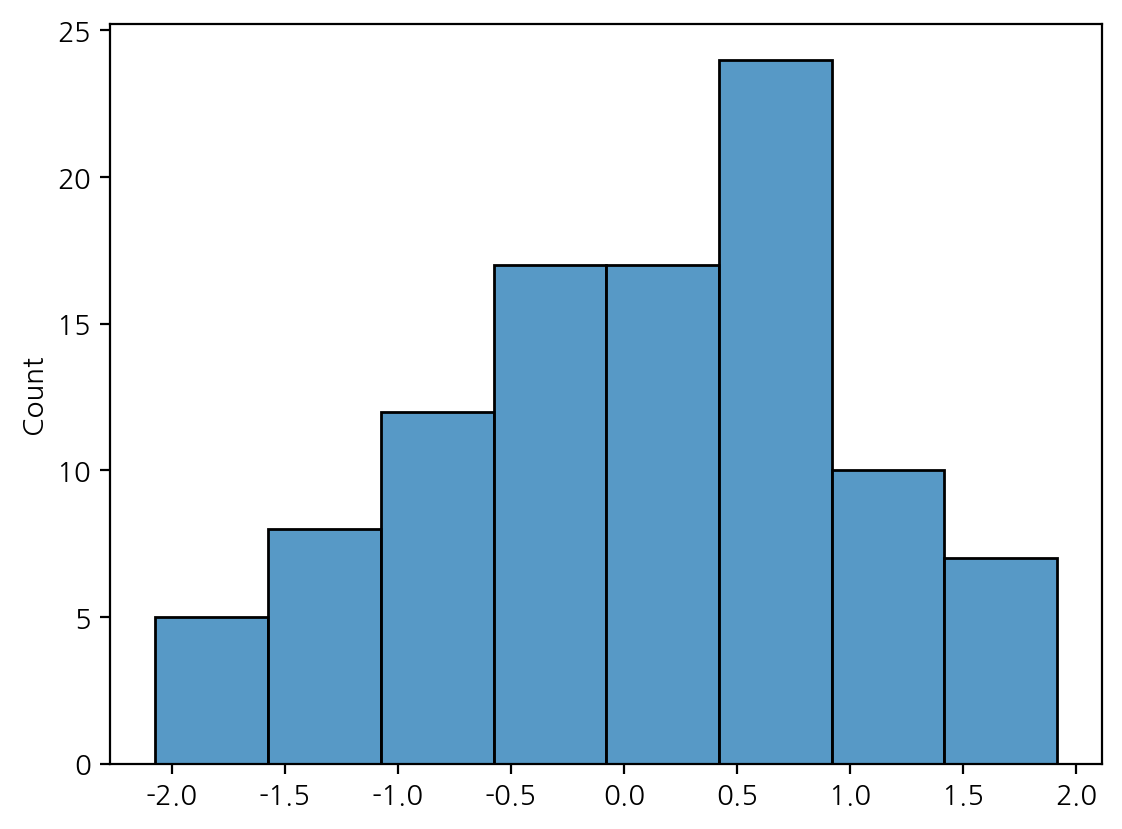

In [125]:
sns.histplot(data)

In [126]:
id(object)

140734204904944